In [62]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import missingno as msno
import joblib

# Establish Country & Pollutant

In [63]:
load_dotenv()

True

In [64]:
POLLUTANT = "O3"

In [65]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")  
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [66]:
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

# Load Data

In [67]:
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [68]:
table_name = f"air_quality_{COUNTRY_CODE}"

In [69]:
query = f"""
SELECT * FROM {table_name} 
WHERE "Pollutant" = 7;
"""

df= pd.read_sql_query(query, engine)

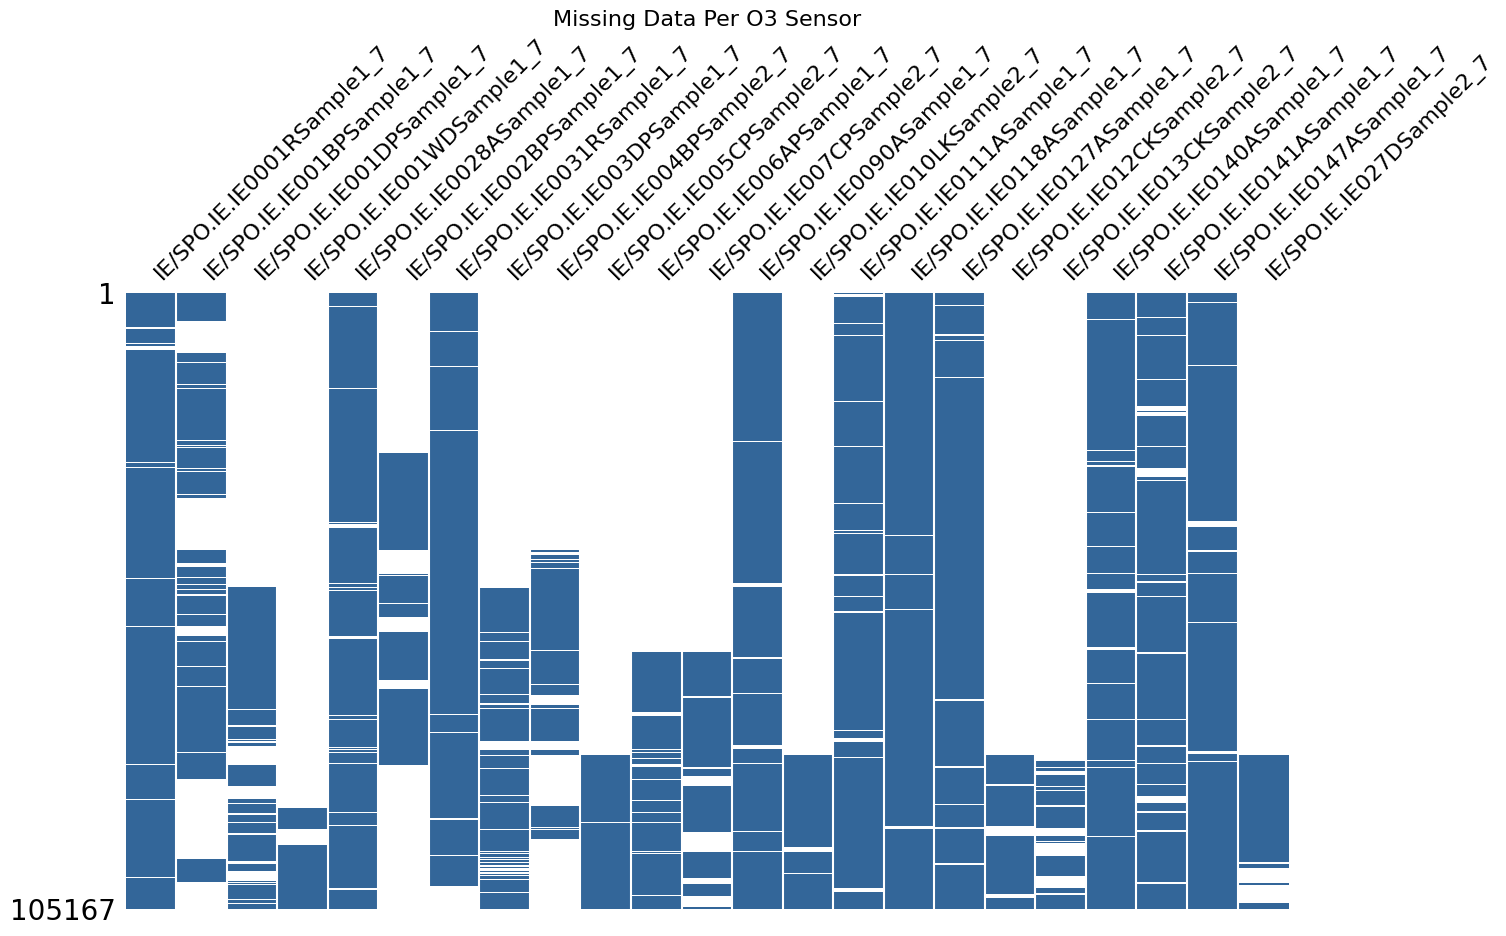

Longest continuous NaN streaks per O3 Station:
Samplingpoint
IE/SPO.IE.IE002BPSample1_7    24662
IE/SPO.IE.IE001BPSample1_7    13757
IE/SPO.IE.IE004BPSample2_7    11643
IE/SPO.IE.IE003DPSample1_7     6469
IE/SPO.IE.IE001DPSample1_7     6445
IE/SPO.IE.IE0031RSample1_7     3937
IE/SPO.IE.IE007CPSample2_7     3394
IE/SPO.IE.IE027DSample2_7      3074
IE/SPO.IE.IE001WDSample1_7     2848
IE/SPO.IE.IE013CKSample2_7     2252
Name: Value, dtype: int64


In [70]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df_pivot = df.pivot_table(index='Start', columns='Samplingpoint', values='Value') # pivot the data to get a matrix of sampling points vs time, with the values being the pollutant measurements.

# Visualize the missing data gaps per sensor with msno matrix to show presence and absence of data
msno.matrix(df_pivot, figsize=(15, 8), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title(f"Missing Data Per {POLLUTANT} Sensor", fontsize=16)
plt.savefig(output_dir / f"{RUN_ID}_msno_matrix.png", bbox_inches='tight')
plt.show()
plt.close()
# longest streak of missing data
def max_consecutive_nans(series):
    is_na = series.isna()
    # Cumulatively (cumsum) sum the non-NaNs to create unique group IDs for consecutive NaNs
    return is_na.groupby((~is_na).cumsum()).sum().max()

longest_nan_streaks = df.groupby('Samplingpoint')['Value'].apply(max_consecutive_nans) 
longest_nan_streaks = longest_nan_streaks.sort_values(ascending=False)

print(f"Longest continuous NaN streaks per {POLLUTANT} Station:")
print(longest_nan_streaks.head(10))

In [71]:
df['Start'] = pd.to_datetime(df['Start'])

In [72]:
print(f"Rows in dataset: {len(df)}")
print(f"NaN rows in dataset: {df['Value'].isna().sum()}")
print(f"Non-NaN rows in dataset: {df['Value'].notna().sum()}")
df.head()

Rows in dataset: 1647553
NaN rows in dataset: 193124
Non-NaN rows in dataset: 1454429


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture
0,IE/SPO.IE.IE0001RSample1_7,7,2013-01-01 01:00:00,2013-01-01 02:00:00,93.80,ug.m-3,hour,1,1,2014-09-30 21:13:08,NaN
1,IE/SPO.IE.IE0001RSample1_7,7,2013-01-01 02:00:00,2013-01-01 03:00:00,93.90,ug.m-3,hour,1,1,2014-09-30 21:13:08,NaN
2,IE/SPO.IE.IE0001RSample1_7,7,2013-01-01 03:00:00,2013-01-01 04:00:00,95.35,ug.m-3,hour,1,1,2014-09-30 21:13:08,NaN
3,IE/SPO.IE.IE0001RSample1_7,7,2013-01-01 04:00:00,2013-01-01 05:00:00,95.70,ug.m-3,hour,1,1,2014-09-30 21:13:08,NaN
4,IE/SPO.IE.IE0001RSample1_7,7,2013-01-01 05:00:00,2013-01-01 06:00:00,96.50,ug.m-3,hour,1,1,2014-09-30 21:13:08,NaN


# Clean Data & Fill gaps when it makes sense to do so

In [73]:
df.loc[(df['Value'] < 0) | (df['Validity'] == -1), 'Value'] = np.nan # Set all invalid and impossible values to NaN

print(f"Total NaN readings after removing data collection errors: {df['Value'].isna().sum()}")

Total NaN readings after removing data collection errors: 200619


In [74]:
df_unified = df.copy() # due to using samplingpoint (previosuly split it up into staionid and sample) this si to work with my code.

In [75]:
def apply_hourly_interpolation(group): # Time-weighted linear interpolation with a 3 hour limit
    
    # Enforce a continuous hourly timeline, required for time-based interpolation
    group = group.set_index('Start').resample('h').asfreq()# asfreq() creates new rows for missing hours with NaN values
    
    group['Value'] = group['Value'].interpolate(method='time', limit=3) 
    
    # Return ONLY the Value column Pandas will automatically re-attach the Samplingpoint
    return group[['Value']]

In [76]:
# Apply interpolation
df_hourly = df_unified.groupby('Samplingpoint').apply(apply_hourly_interpolation).reset_index()

print(f"Hourly dataset size after resampling and patching: {len(df_hourly)}") # may have more rows due to .resample('h').asfreq() filling in missing hours with NaNs
print(f"Remaining NaNs to handle later: {df_hourly['Value'].isna().sum()}")
df_hourly.head(10)

Hourly dataset size after resampling and patching: 1656313
Remaining NaNs to handle later: 199148


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE0001RSample1_7,2013-01-01 01:00:00,93.80
1,IE/SPO.IE.IE0001RSample1_7,2013-01-01 02:00:00,93.90
2,IE/SPO.IE.IE0001RSample1_7,2013-01-01 03:00:00,95.35
3,IE/SPO.IE.IE0001RSample1_7,2013-01-01 04:00:00,95.70
4,IE/SPO.IE.IE0001RSample1_7,2013-01-01 05:00:00,96.50
5,IE/SPO.IE.IE0001RSample1_7,2013-01-01 06:00:00,94.00
6,IE/SPO.IE.IE0001RSample1_7,2013-01-01 07:00:00,95.15
7,IE/SPO.IE.IE0001RSample1_7,2013-01-01 08:00:00,95.30
8,IE/SPO.IE.IE0001RSample1_7,2013-01-01 09:00:00,94.90
9,IE/SPO.IE.IE0001RSample1_7,2013-01-01 10:00:00,95.30


# Aggregation & Fill in gaps when possible

In [77]:
df_hourly['Start'] = pd.to_datetime(df_hourly['Start'])
df_hourly.set_index('Start', inplace=True)

In [78]:
def aggregate_daily_max_8hr(station_group): 
    hourly_data = station_group['Value'].resample('h').asfreq() # have every calender hour, filling in Nan
    
    rolling_8hr = hourly_data.rolling(window=8, min_periods=6).mean()# 8hr rolling mean, atleast 6hrs data per 8
    
    daily_stats = rolling_8hr.resample('D').agg( #  so i get the highest of all 24 overlapping (rolling) 8hr avgs, count hours in day
        Daily_Value='max', 
        Valid_8hr_Means='count'
    )
    
    daily_stats.loc[daily_stats['Valid_8hr_Means'] < 18, 'Daily_Value'] = np.nan # 75% rule 18hrs daily, if less then nan
    
    return daily_stats[['Daily_Value']].rename(columns={'Daily_Value': 'Value'}) # reset column nasmes 

In [90]:
df_hourly = df_hourly.reset_index()

In [80]:
# Apply agg per station
df_daily = df_hourly.groupby('Samplingpoint').apply(aggregate_daily_max_8hr).reset_index()

print(f"Aggregated to {len(df_daily)} daily rows.")
print(f"Days that are NaN including days with less than 75% data: {df_daily['Value'].isna().sum()}")
df_daily.head()

Aggregated to 69014 daily rows.
Days that are NaN including days with less than 75% data: 8810


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE0001RSample1_7,2013-01-01,95.387500
1,IE/SPO.IE.IE0001RSample1_7,2013-01-02,87.985416
2,IE/SPO.IE.IE0001RSample1_7,2013-01-03,75.081250
3,IE/SPO.IE.IE0001RSample1_7,2013-01-04,80.268750
4,IE/SPO.IE.IE0001RSample1_7,2013-01-05,82.175000


In [81]:
# Daily Time weighted linear interpolation, 2 missing days max
def apply_daily_interpolation(station_group):
    station_group = station_group.set_index('Start') # Make Datetime index again for Pd

    station_group['Value'] = station_group['Value'].interpolate(method='time', limit=2)
    return station_group[['Value']]

In [82]:
# Apply the interpolation per station
df_daily_Final = df_daily.groupby('Samplingpoint').apply(apply_daily_interpolation).reset_index()

print(f"Dataset size after coverting to daily and interpolation: {len(df_daily_Final)}")
print(f"Remaining persistent NaNs with gaps for than 2 days: {df_daily_Final['Value'].isna().sum()}")
df_daily_Final.head()

Dataset size after coverting to daily and interpolation: 69014
Remaining persistent NaNs with gaps for than 2 days: 7601


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE0001RSample1_7,2013-01-01,95.387500
1,IE/SPO.IE.IE0001RSample1_7,2013-01-02,87.985416
2,IE/SPO.IE.IE0001RSample1_7,2013-01-03,75.081250
3,IE/SPO.IE.IE0001RSample1_7,2013-01-04,80.268750
4,IE/SPO.IE.IE0001RSample1_7,2013-01-05,82.175000


# Saving Cleaned Data

In [83]:
target_folder = os.getenv("BASE_DATA_PATH") # target folder saved in .env

# Dynamically naming country and polulutant for auto name and save
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(target_folder, file_name)

df_daily_Final.to_parquet(file_path, index=False) # save cleaned data as parquet

# Before, During & After Plotted

In [84]:
print("Before Interpolation hourly (df_unified)")
print(f"Total NaNs: {df_unified['Value'].isna().sum()}")
print(df_unified['Value'].describe())

print("\nAfter Interpolation hourly (df_dhourly)")
print(f"Total NaNs: {df_hourly['Value'].isna().sum()}")
print(df_hourly['Value'].describe())

Before Interpolation hourly (df_unified)
Total NaNs: 200619
count    1.446934e+06
mean     5.503621e+01
std      2.149636e+01
min      0.000000e+00
25%      4.140000e+01
50%      5.650000e+01
75%      7.020000e+01
max      4.463000e+02
Name: Value, dtype: float64

After Interpolation hourly (df_dhourly)
Total NaNs: 199148
count    1.457165e+06
mean     5.493509e+01
std      2.160368e+01
min      0.000000e+00
25%      4.122500e+01
50%      5.640000e+01
75%      7.020000e+01
max      4.463000e+02
Name: Value, dtype: float64


In [85]:
print("Before Interpolation (df_daily)")
print(f"Total NaNs: {df_daily['Value'].isna().sum()}")
print(df_daily['Value'].describe())

print("\nAfter Interpolaton (df_daily_Final)")
print(f"Total NaNs: {df_daily_Final['Value'].isna().sum()}")
print(df_daily_Final['Value'].describe())

Before Interpolation (df_daily)
Total NaNs: 8810
count    60204.000000
mean        66.497148
std         17.548876
min          0.137500
25%         55.400000
50%         66.635625
75%         78.160625
max        340.624008
Name: Value, dtype: float64

After Interpolaton (df_daily_Final)
Total NaNs: 7601
count    61413.000000
mean        66.449954
std         17.573039
min          0.137500
25%         55.317500
50%         66.600000
75%         78.125000
max        340.624008
Name: Value, dtype: float64


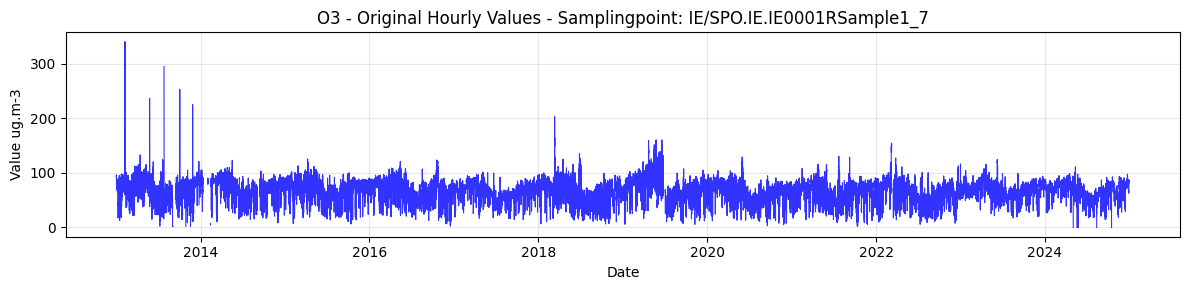

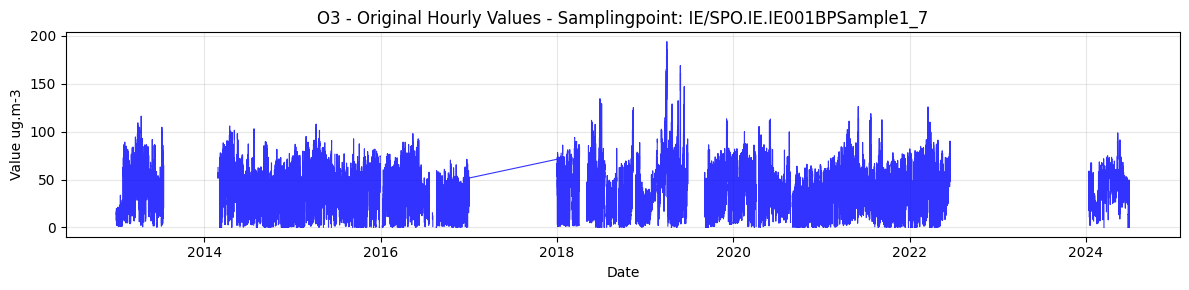

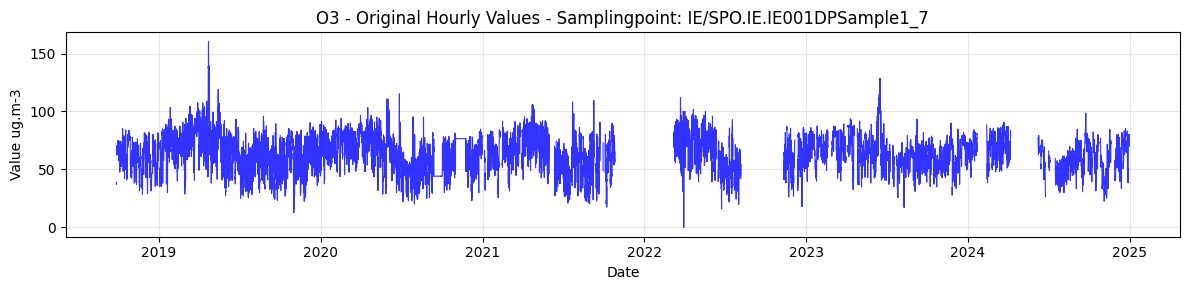

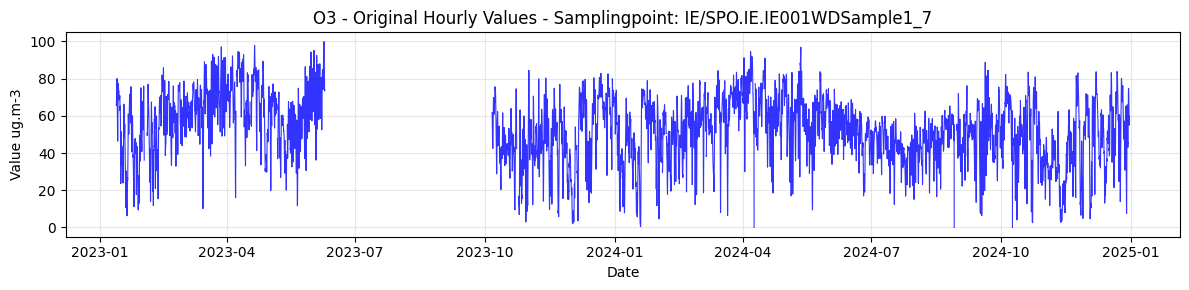

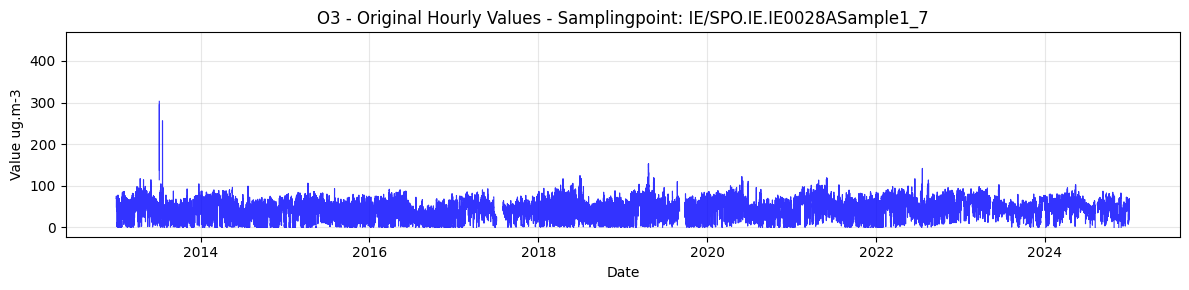

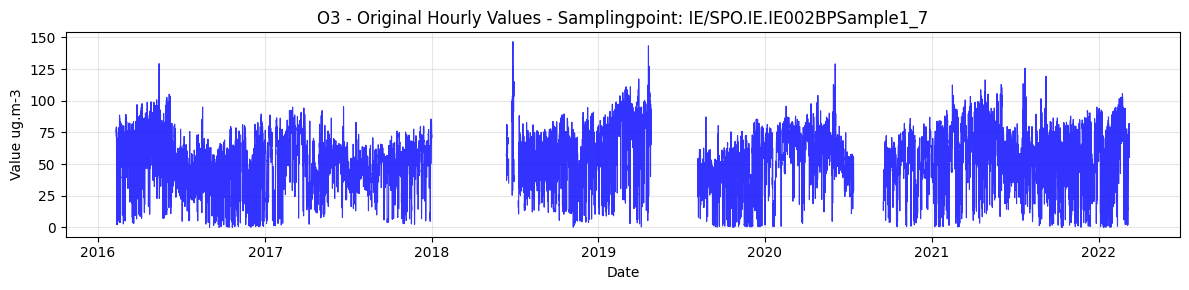

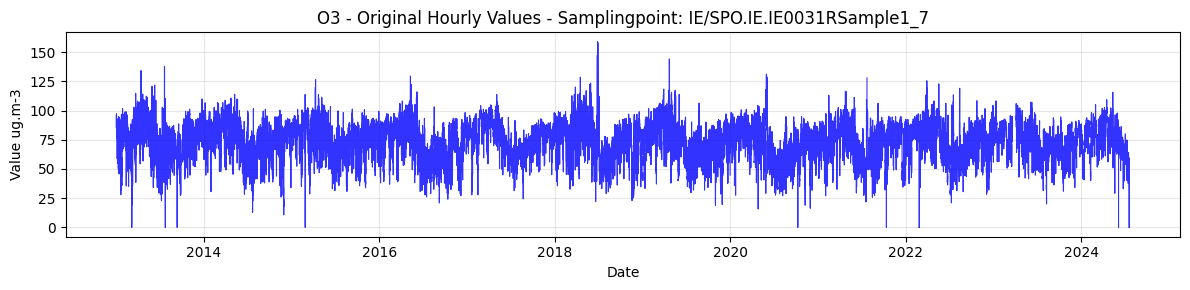

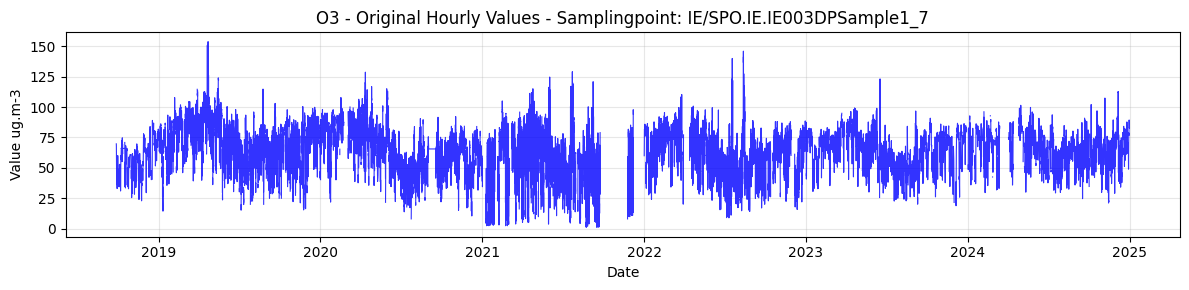

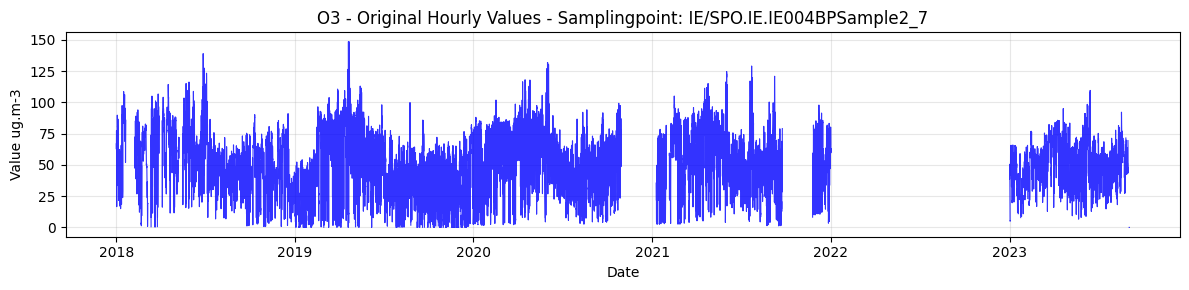

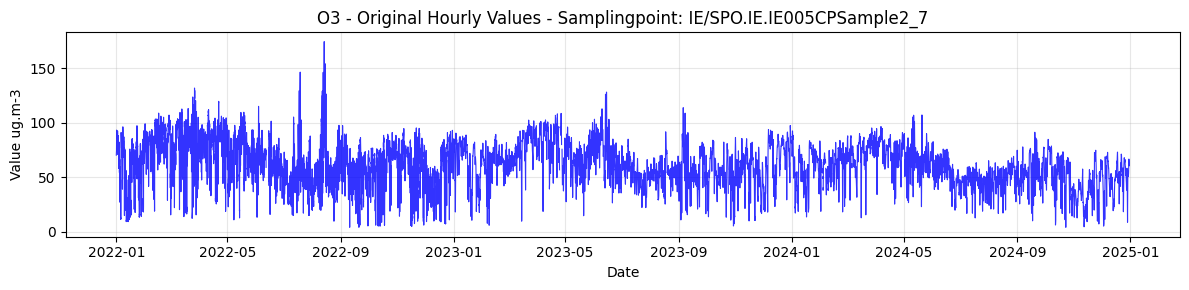

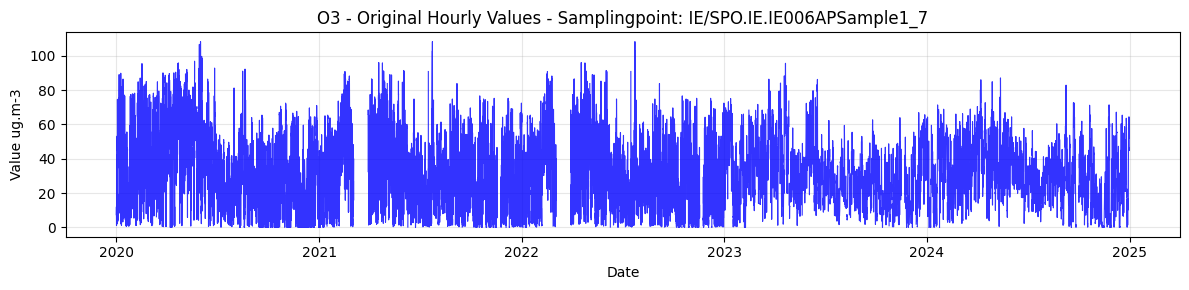

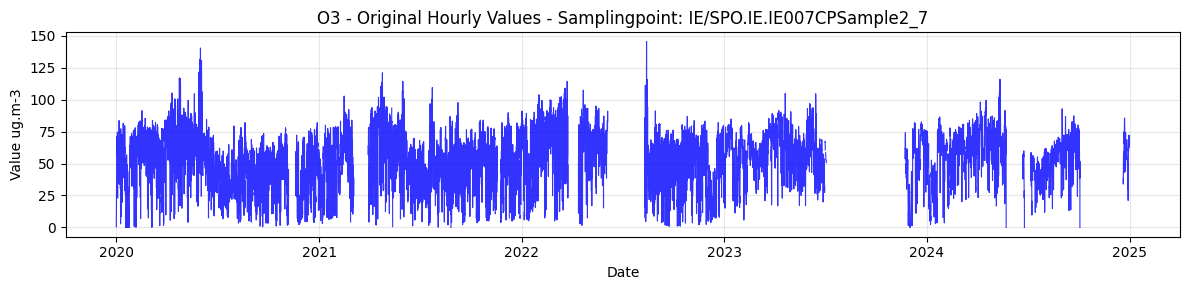

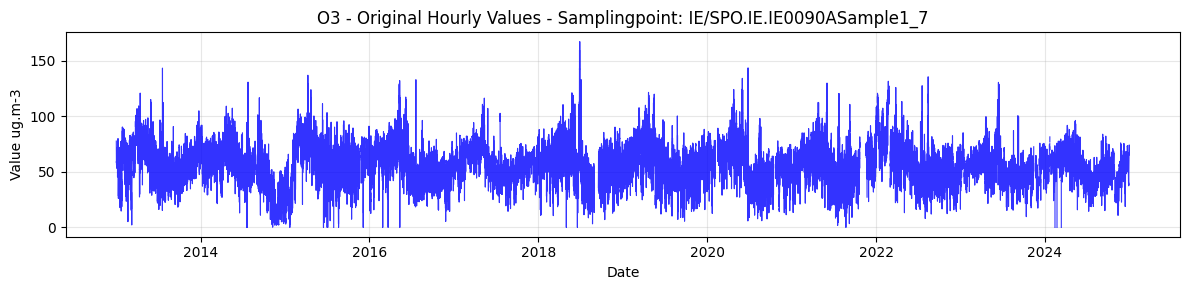

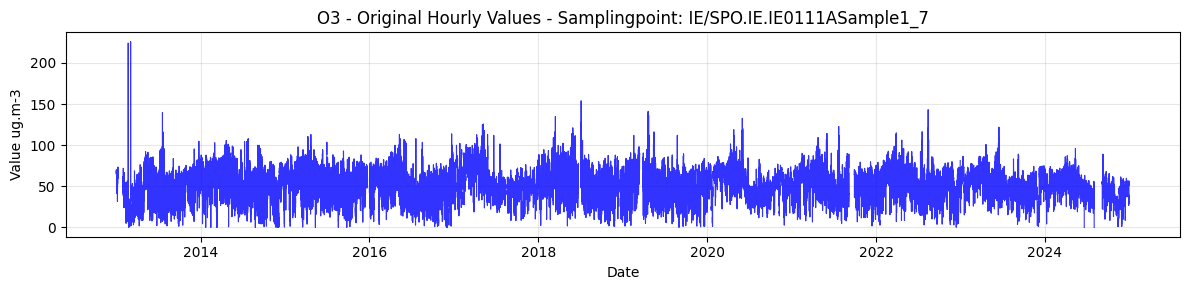

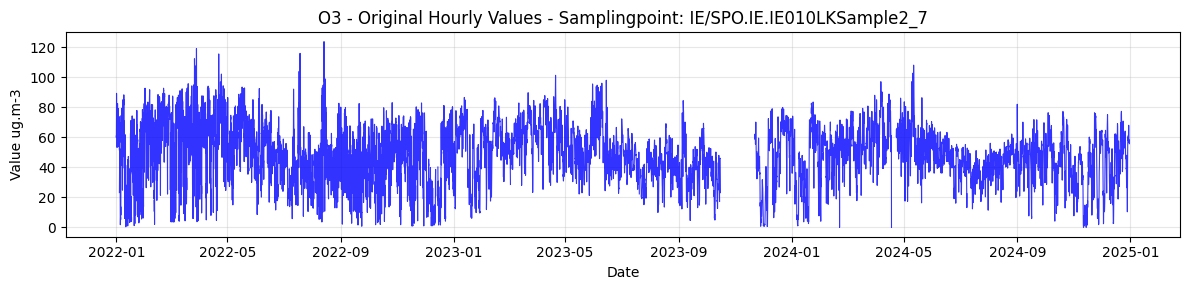

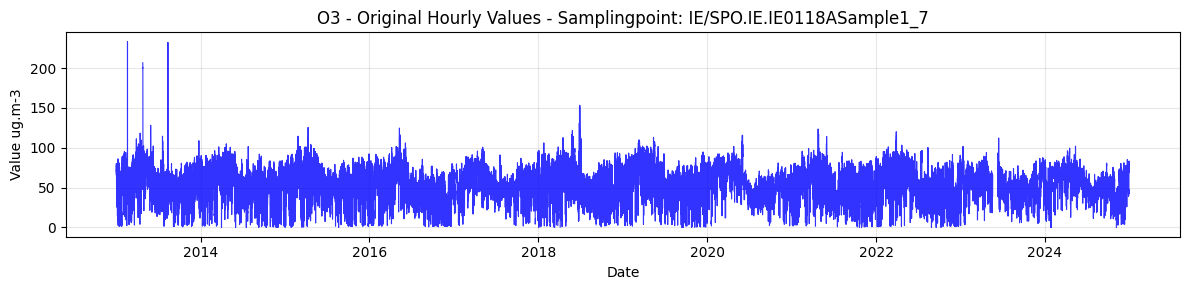

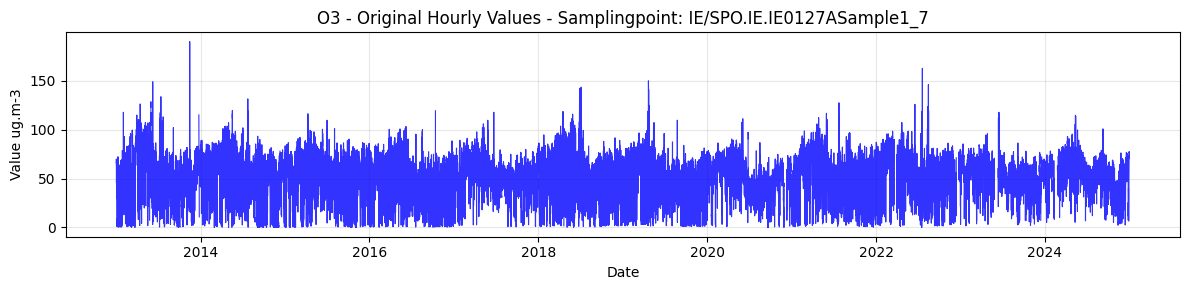

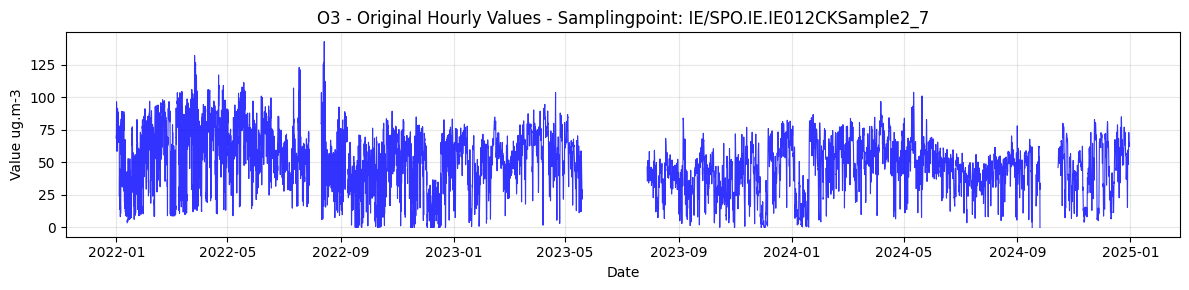

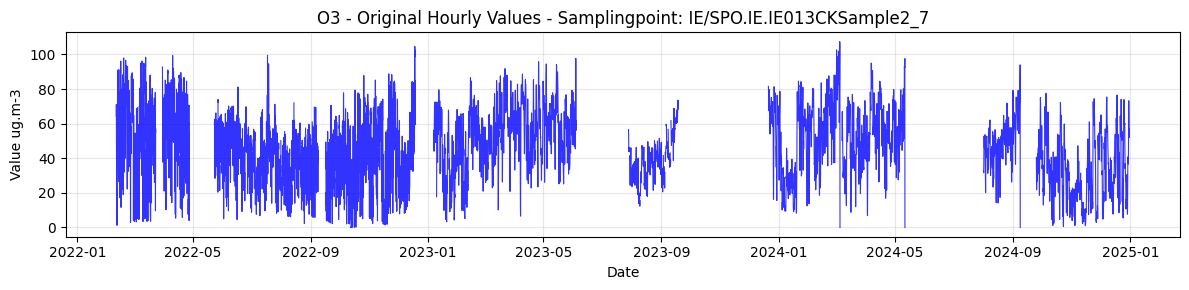

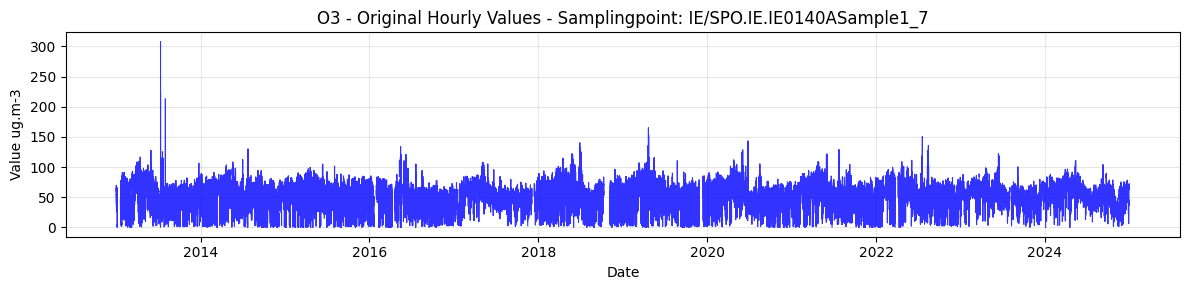

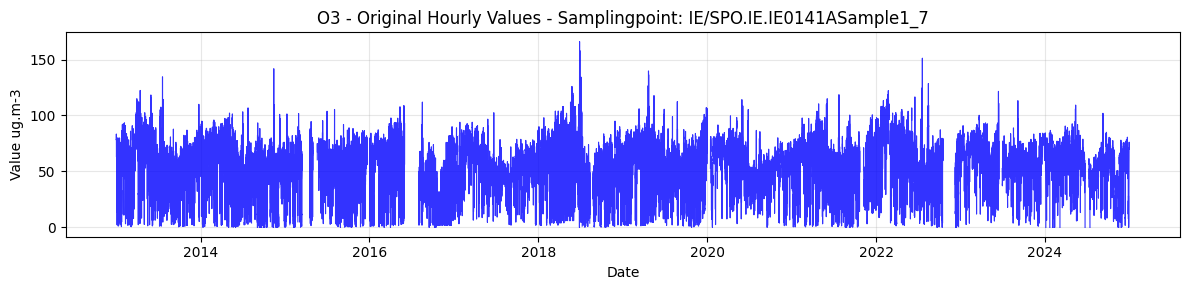

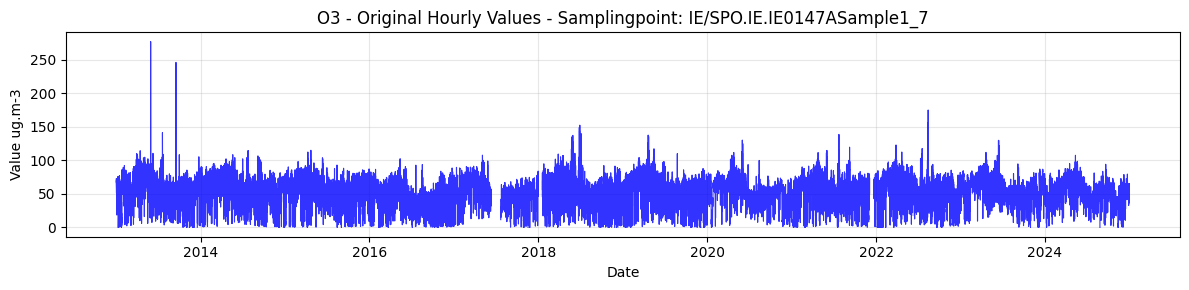

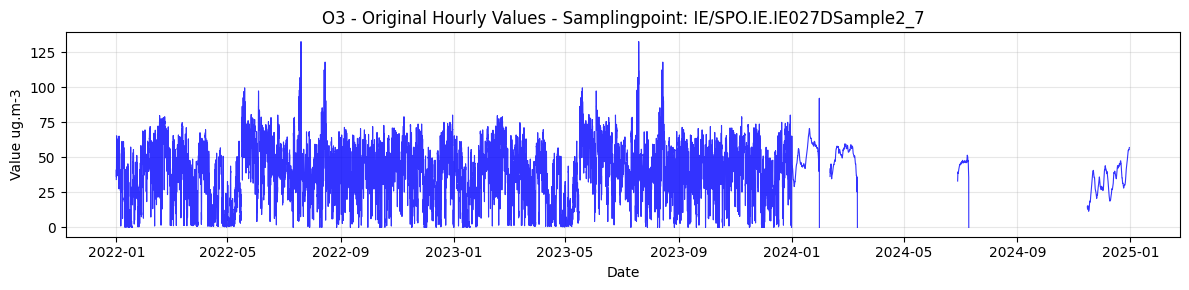

In [86]:
#Create a specific folder for these plots so they don't clutter your main directory
plot_dir = output_dir / "Original_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_unified['Samplingpoint'].unique()

for station in stations:
    station_data = df_unified[df_unified['Samplingpoint'] == station]
    
   
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='blue', alpha=0.8, linewidth=0.8)

    plt.title(f'{POLLUTANT} - Original Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Dynamic save for each plot in the loop
    # We clean the station name (replace dots/slashes with underscores) to avoid file errors
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_hourly.png"
    
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    
    plt.show() 
    plt.close() 

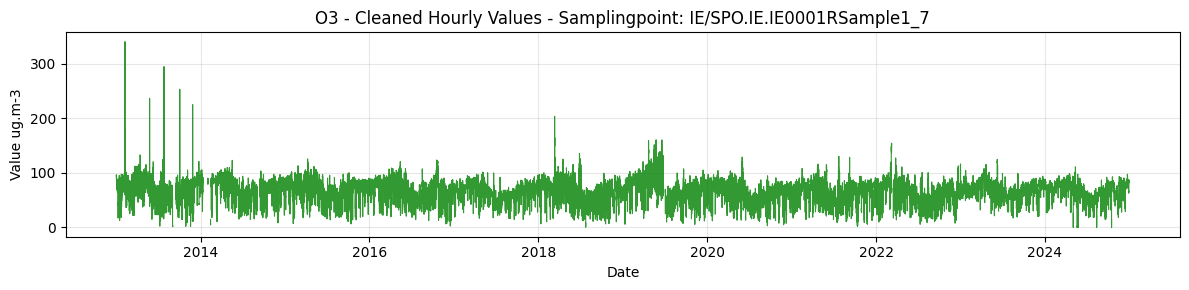

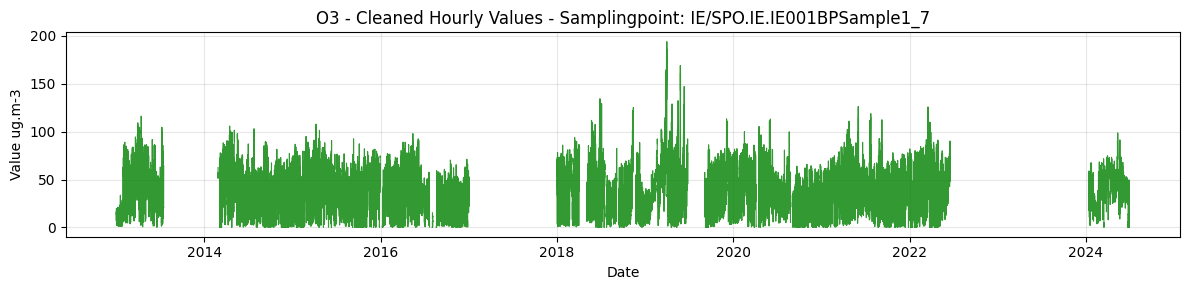

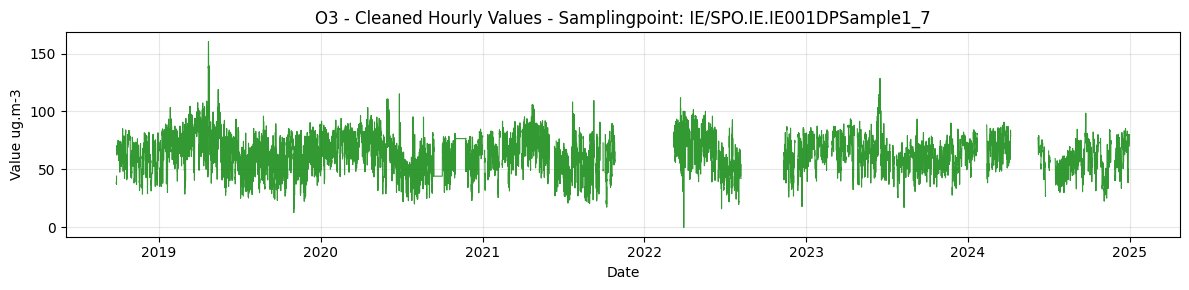

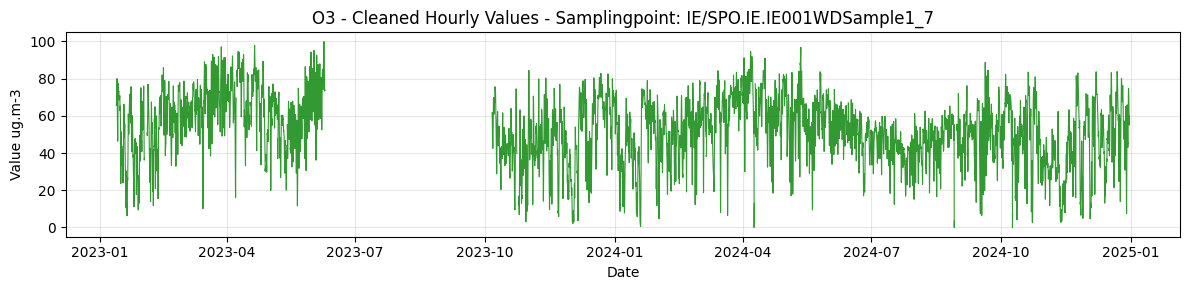

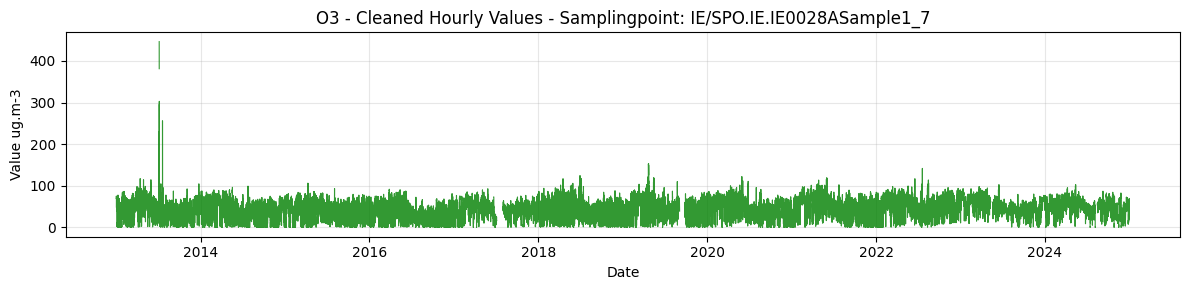

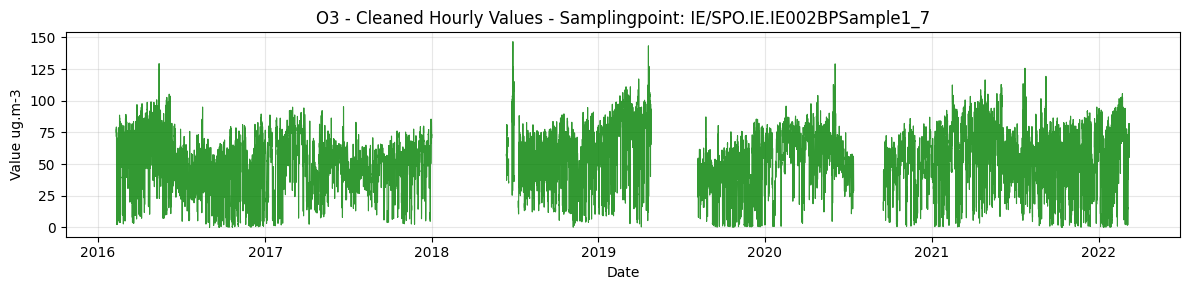

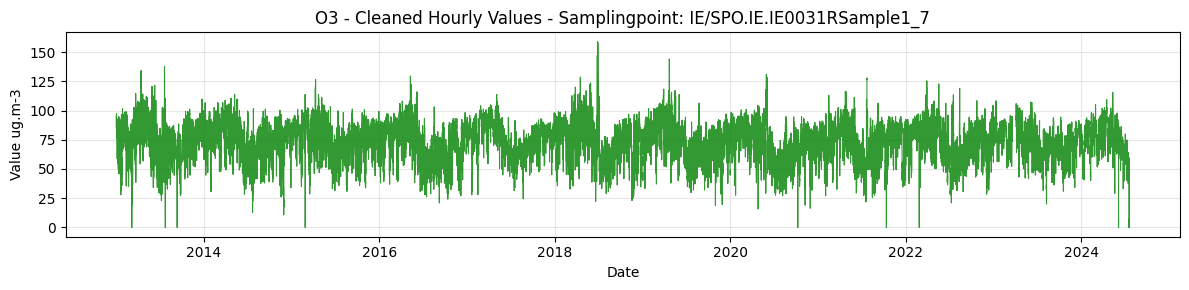

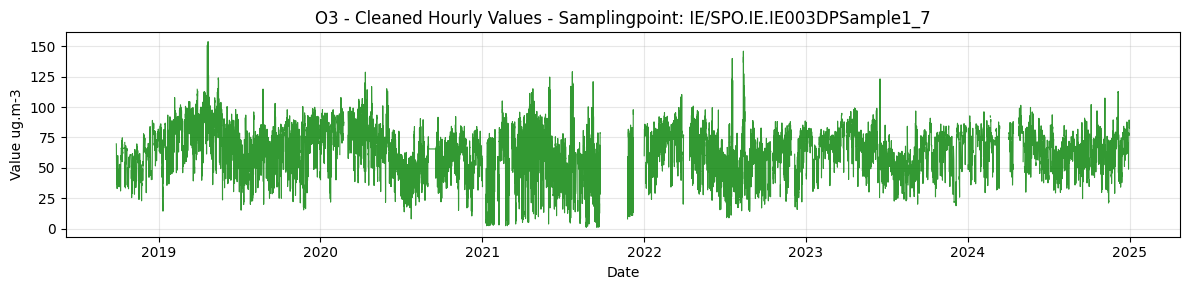

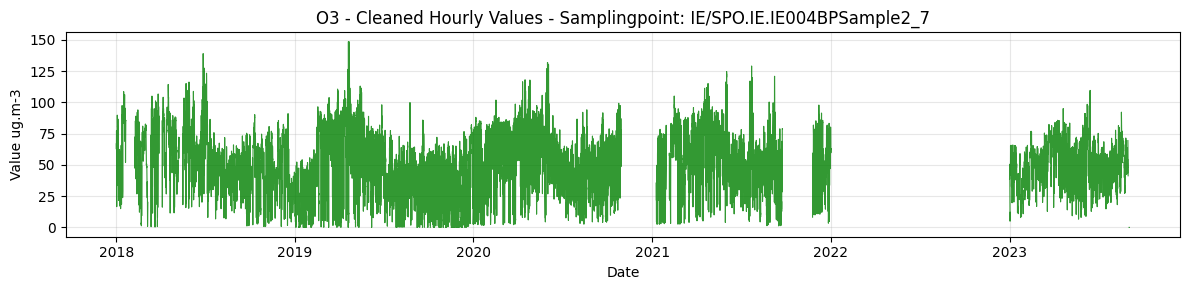

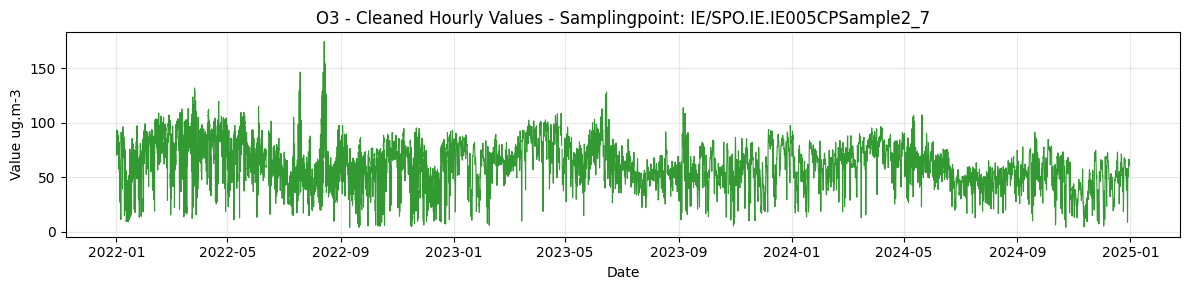

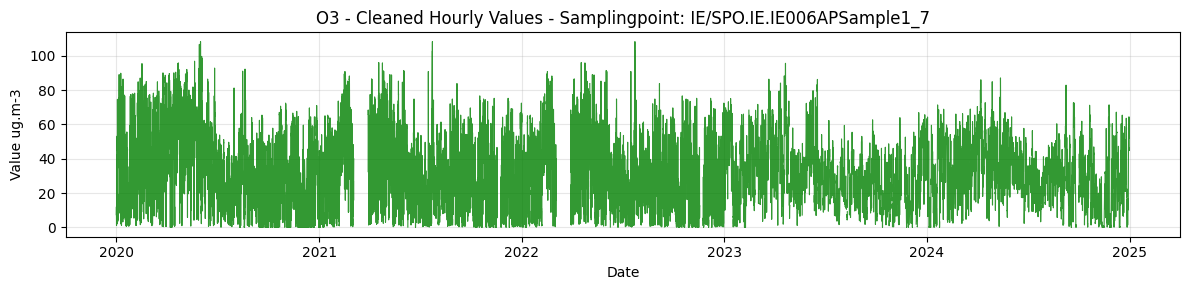

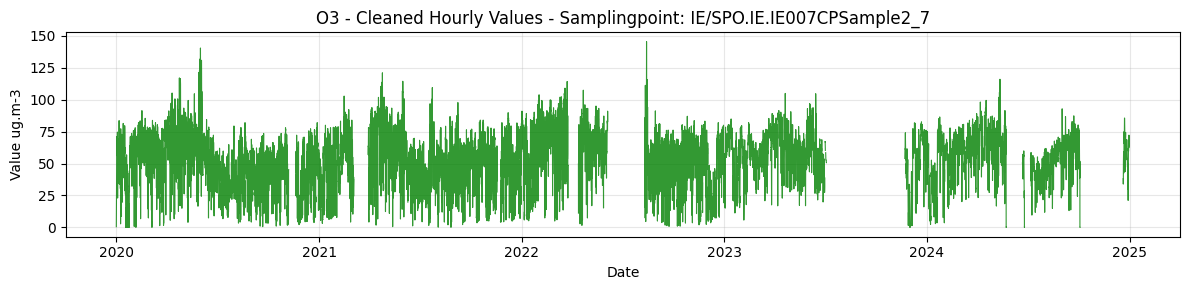

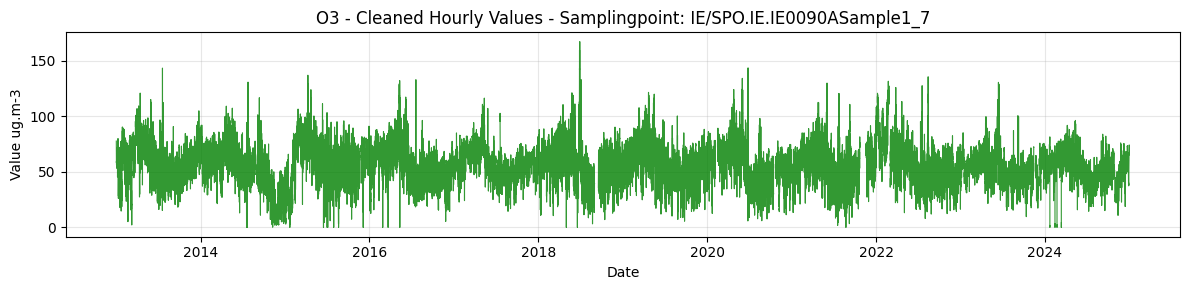

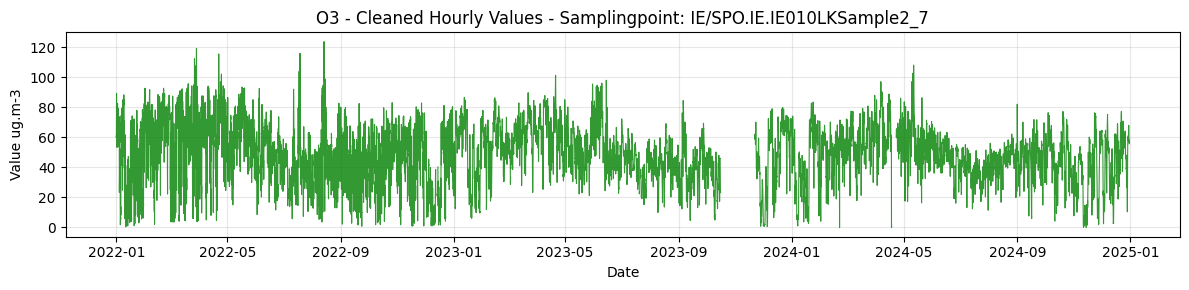

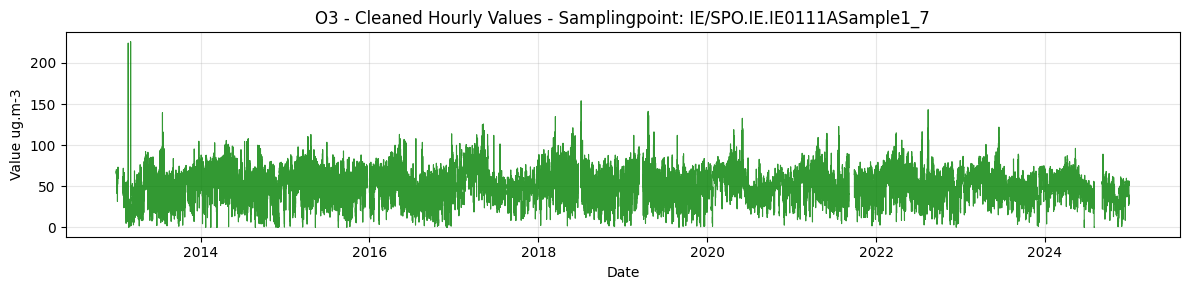

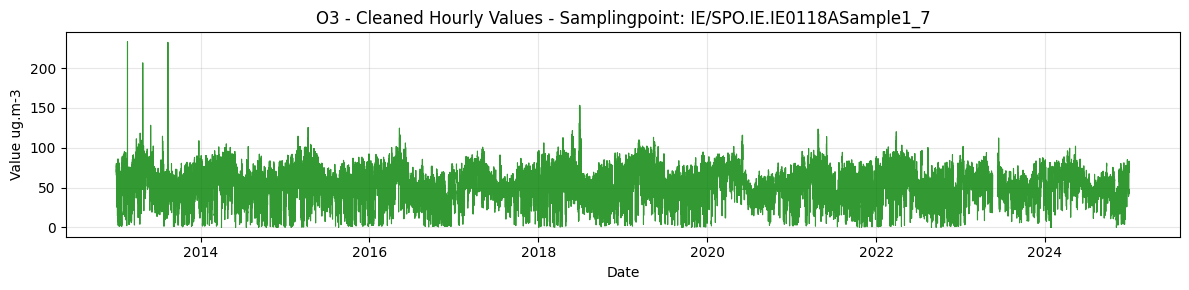

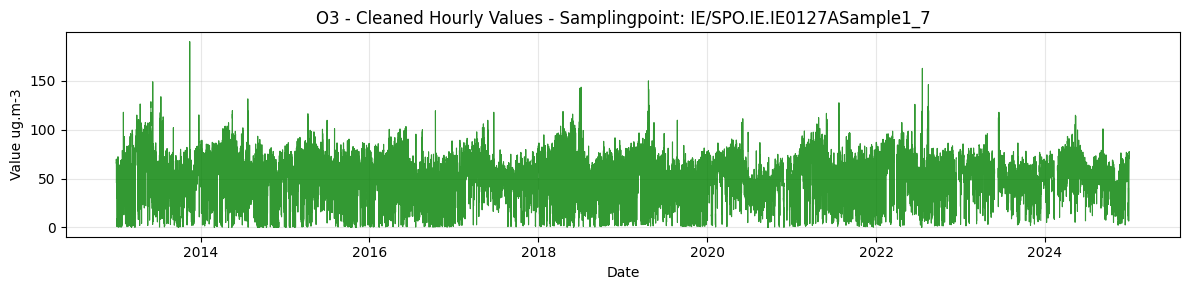

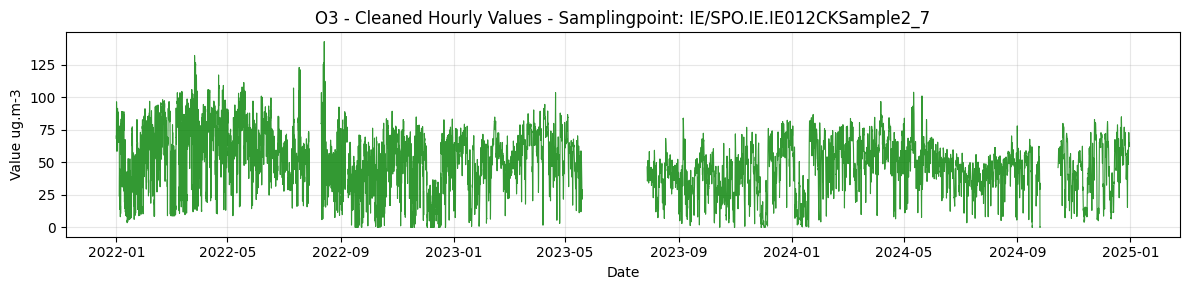

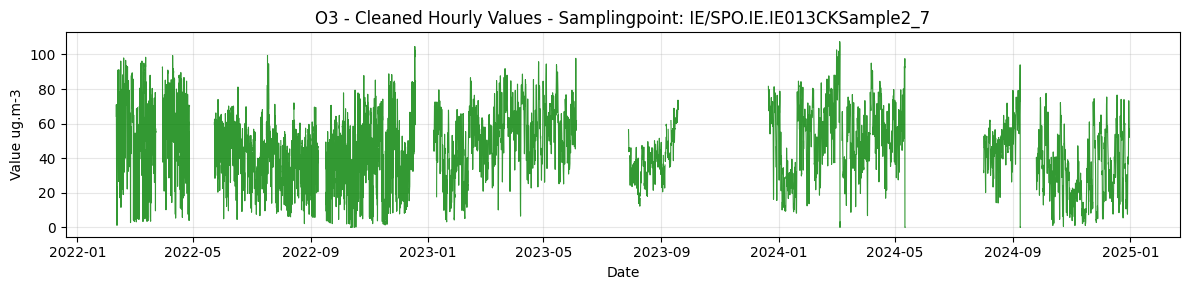

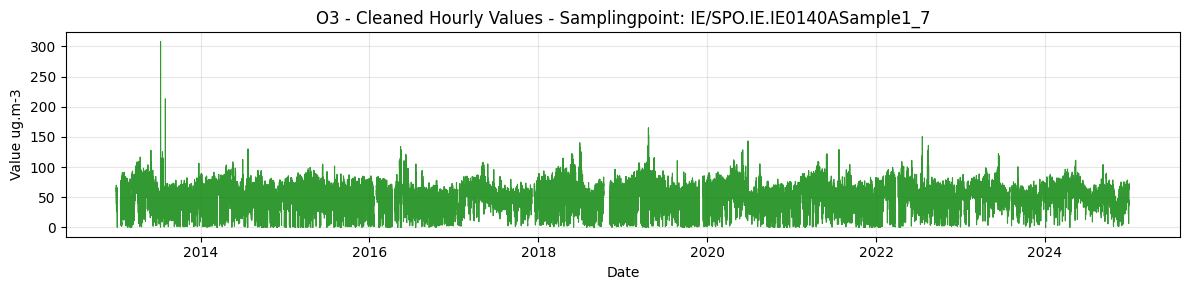

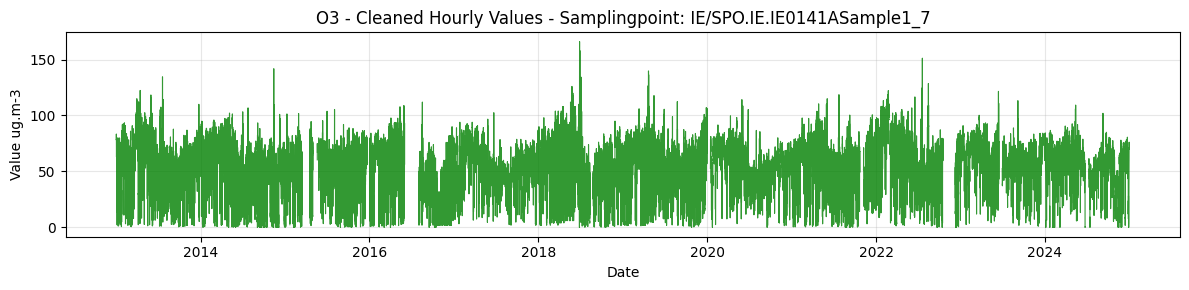

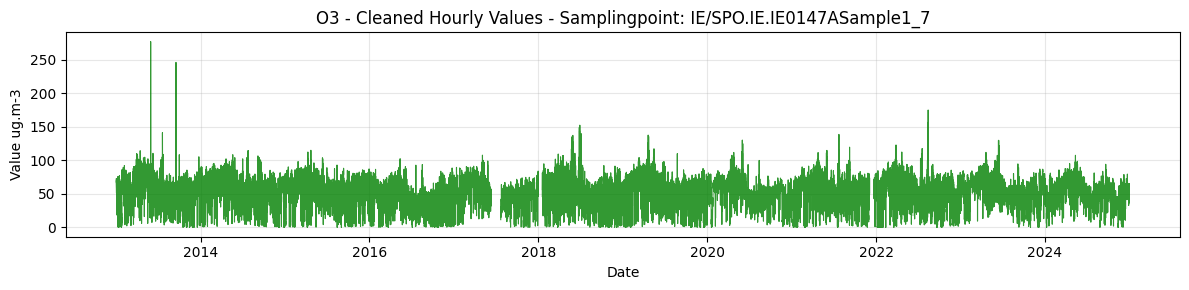

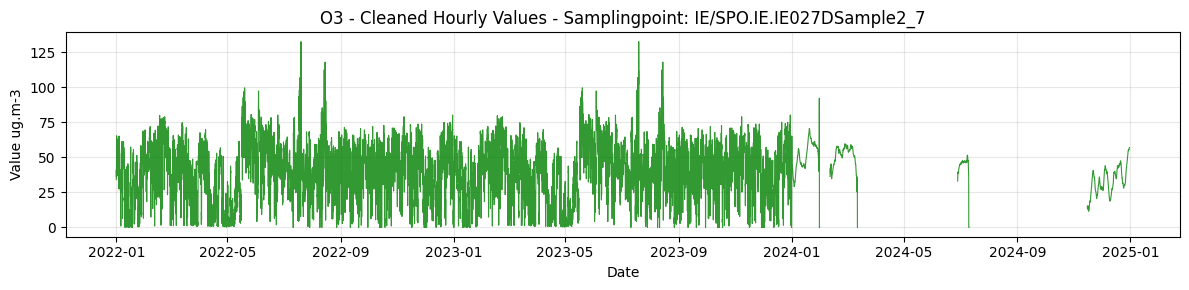

In [91]:
plot_dir = output_dir / "Cleaned_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_hourly['Samplingpoint'].unique()

for station in stations:
    station_data = df_hourly[df_hourly['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='green', alpha=0.8, linewidth=0.8)
    plt.title(f'{POLLUTANT} - Cleaned Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleaned_hourly.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.show()
    plt.close()

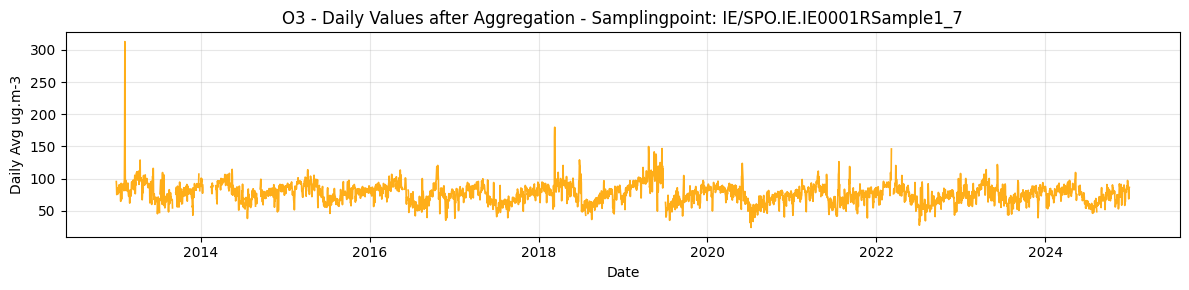

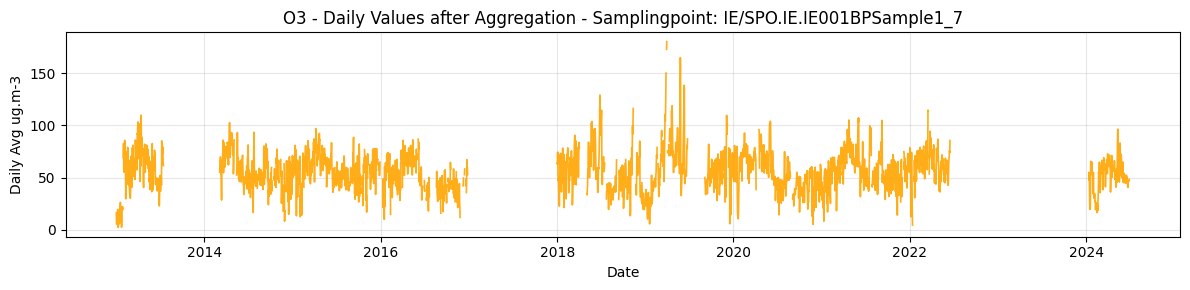

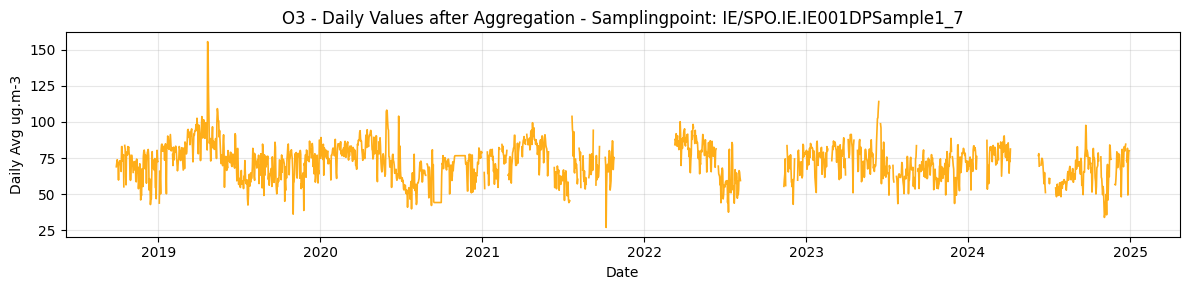

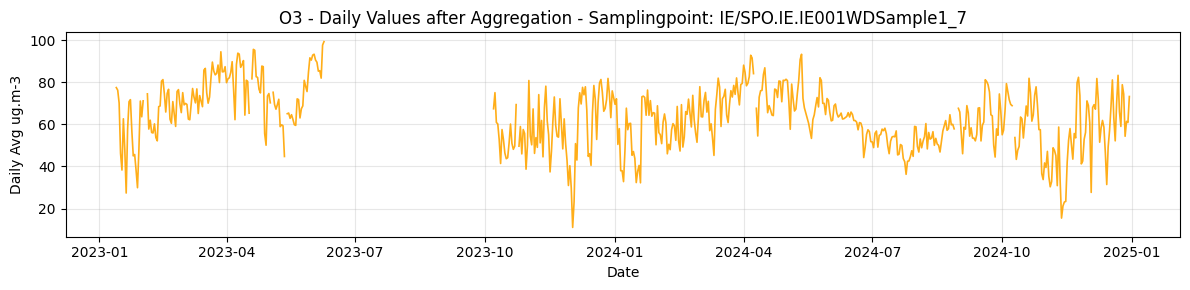

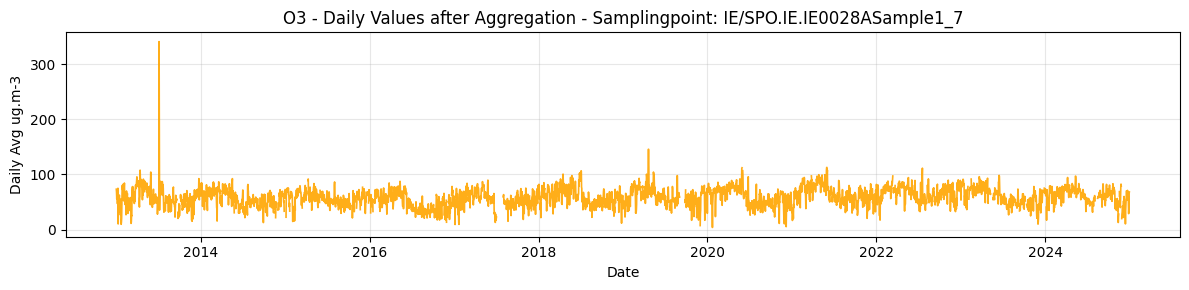

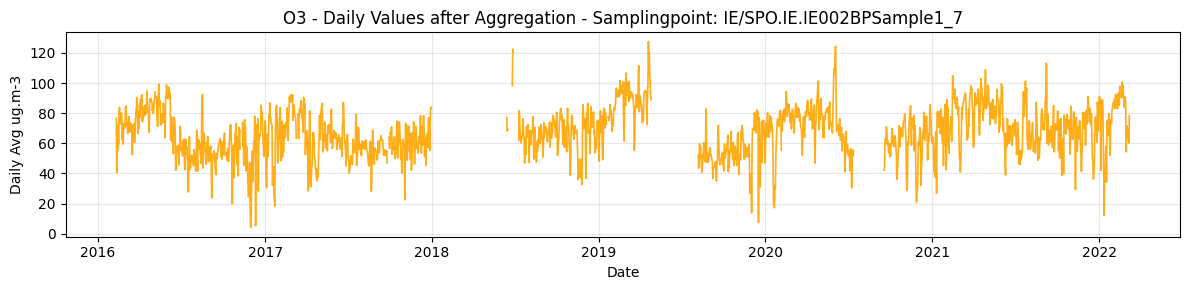

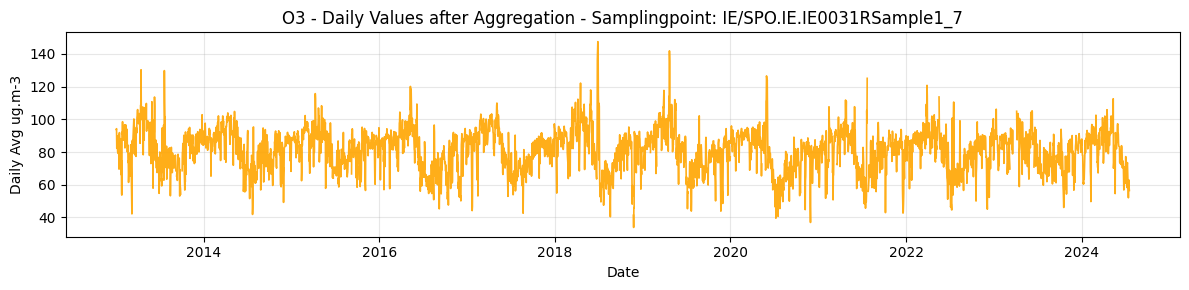

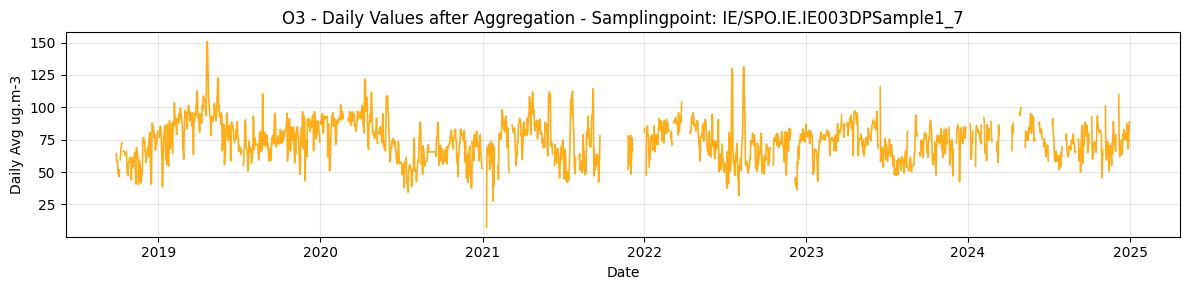

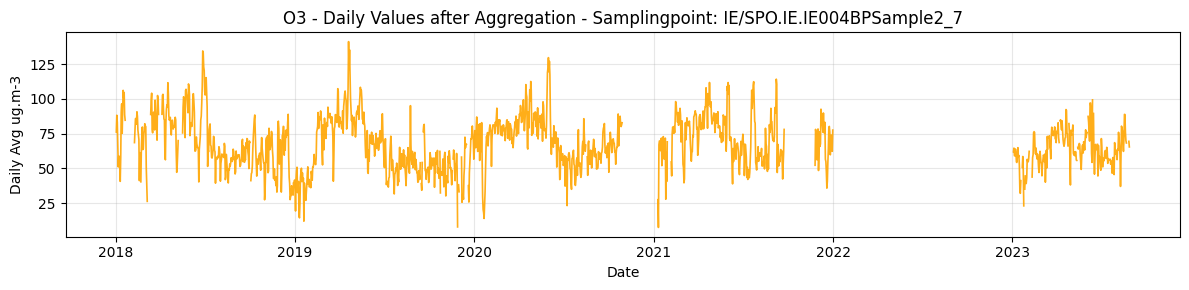

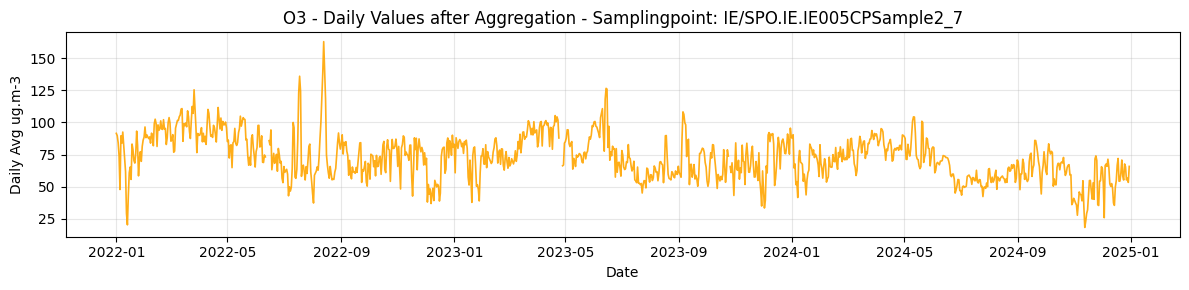

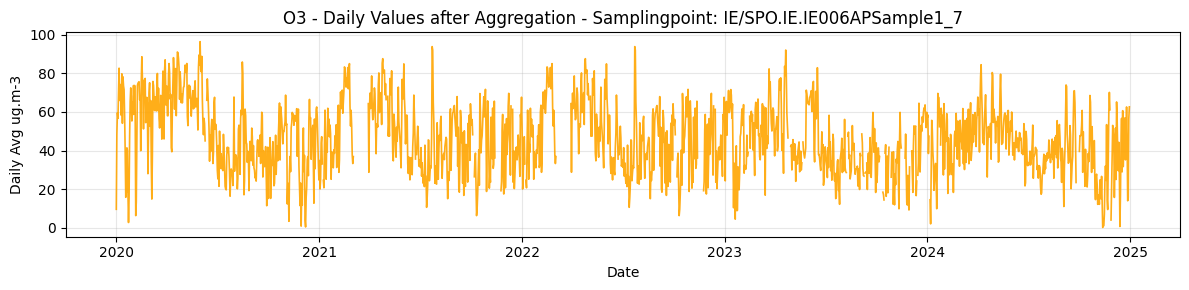

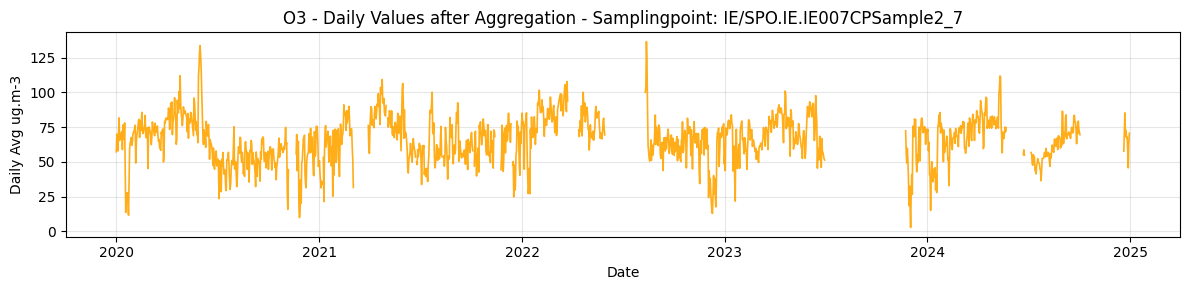

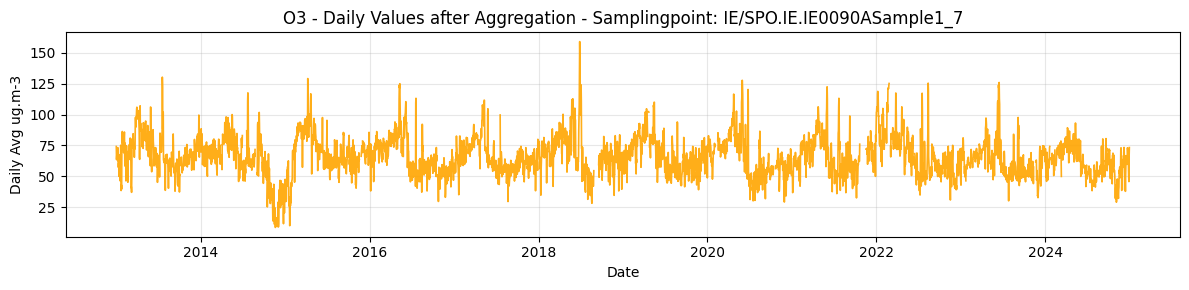

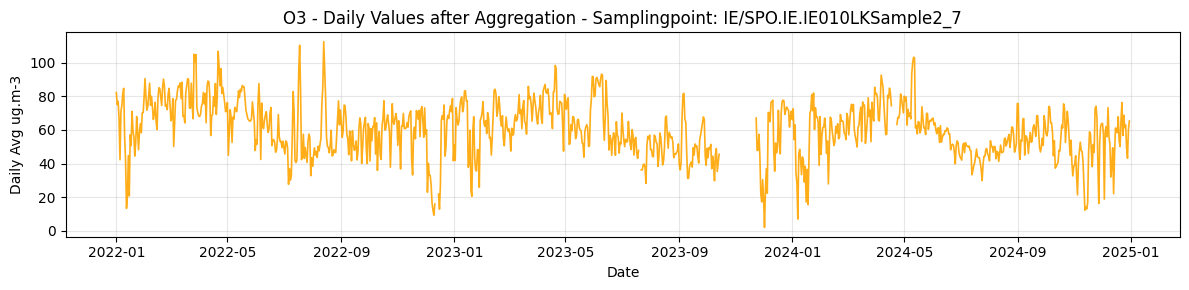

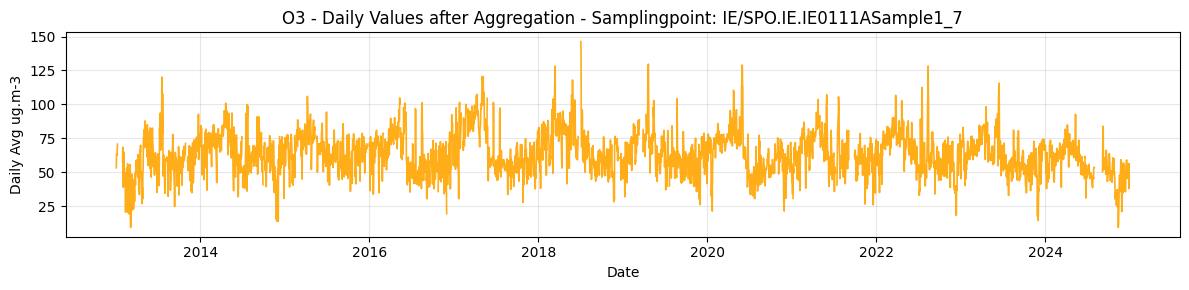

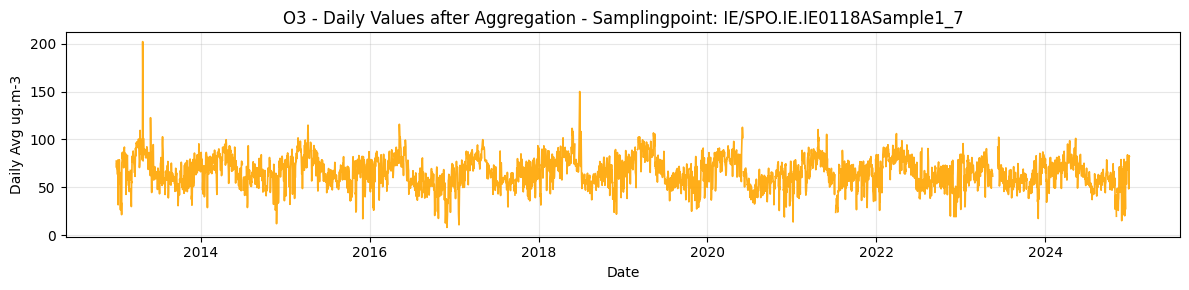

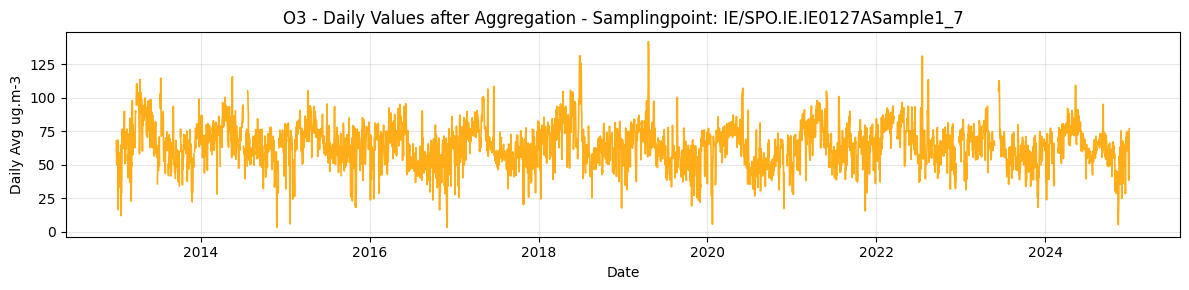

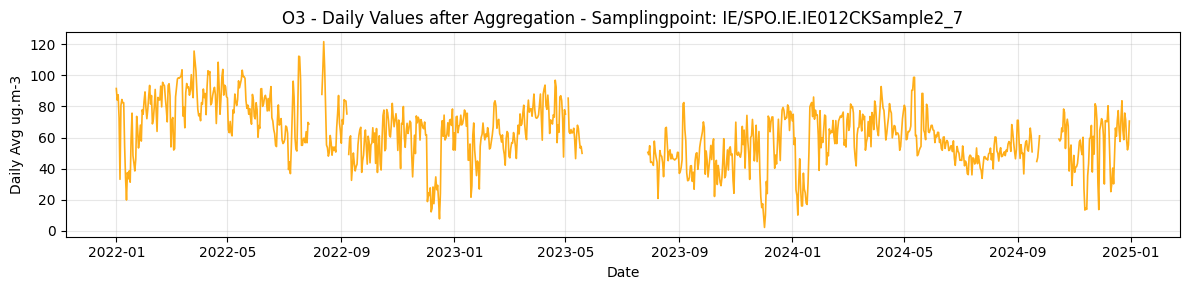

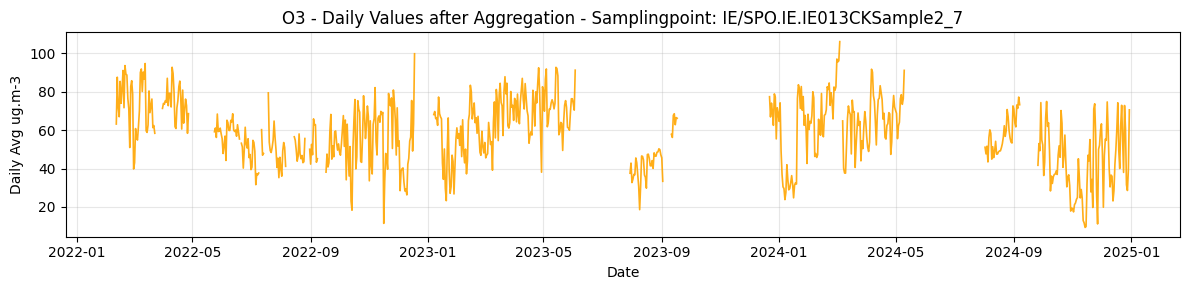

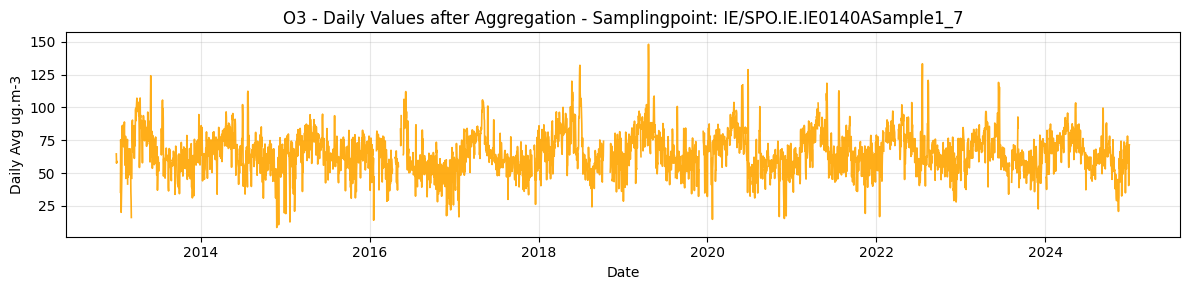

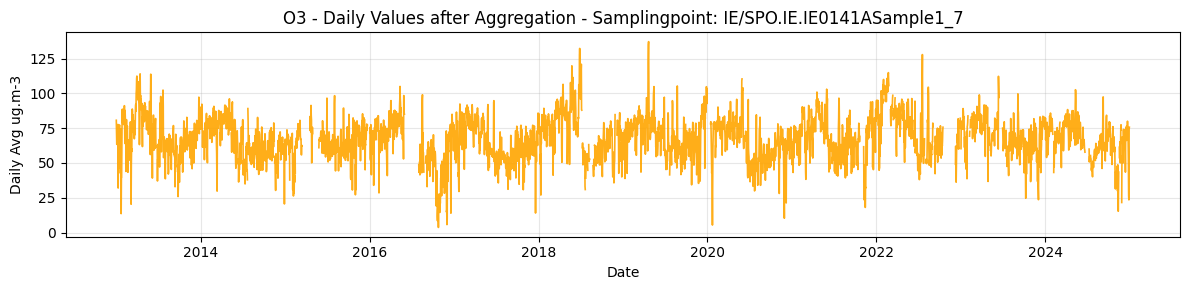

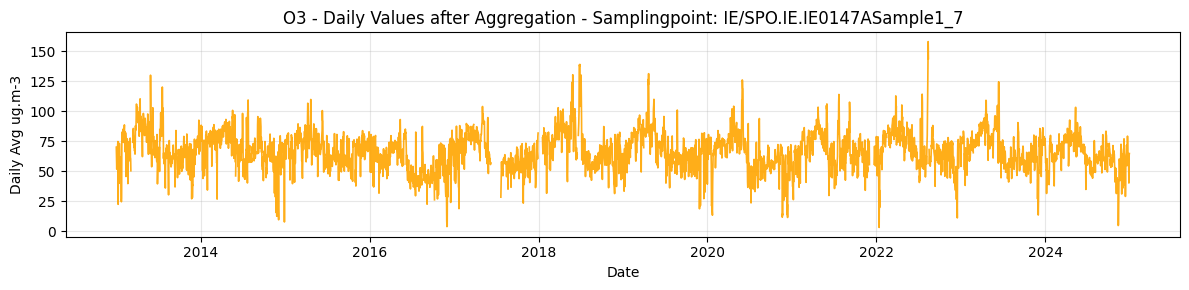

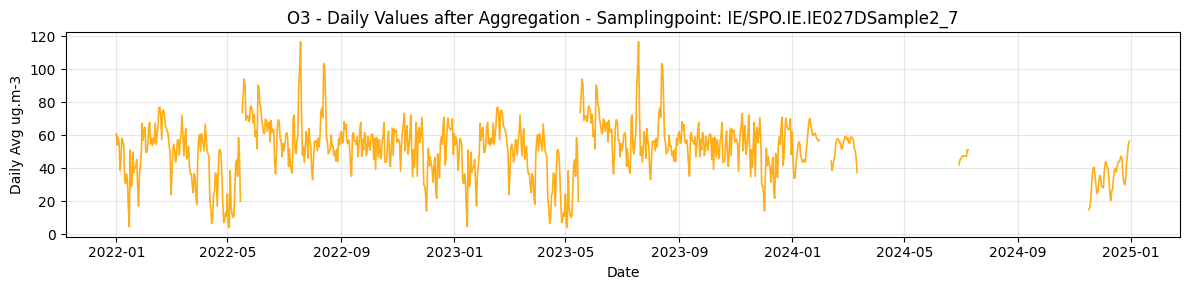

In [88]:
plot_dir = output_dir / "Daily_Aggregated_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily[df_daily['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='orange', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Daily Values after Aggregation - Samplingpoint: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_aggregated_daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()

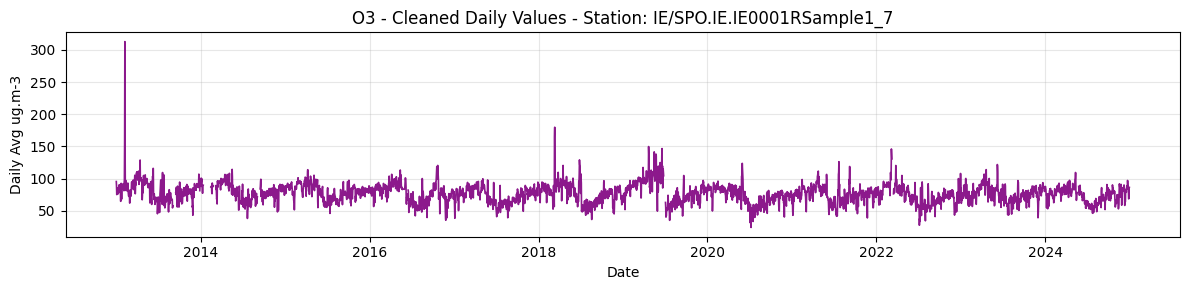

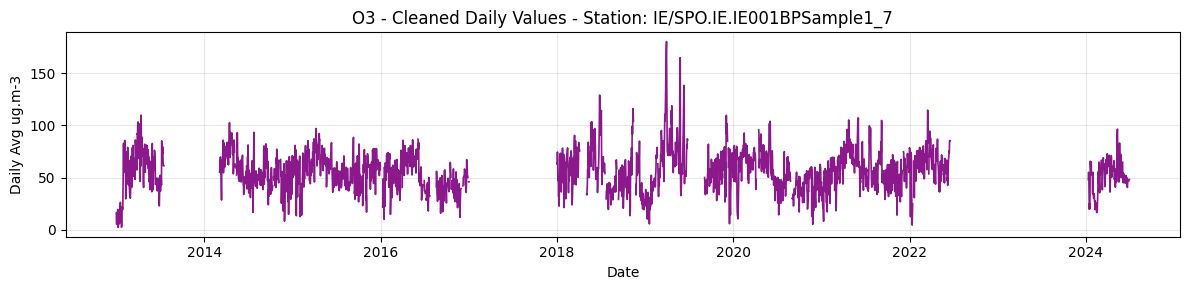

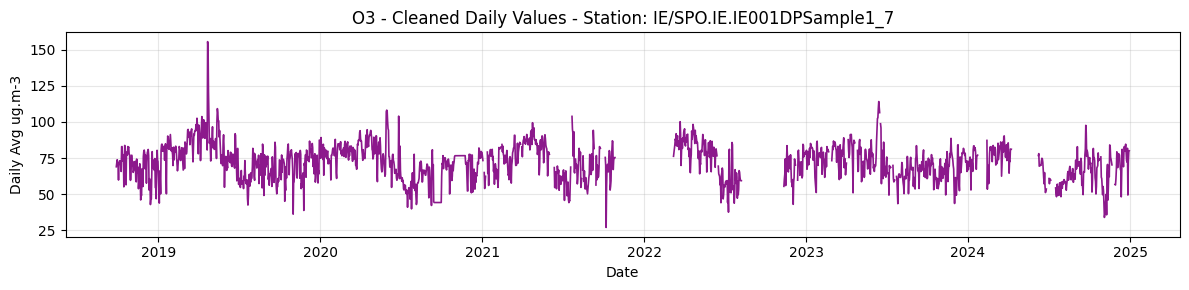

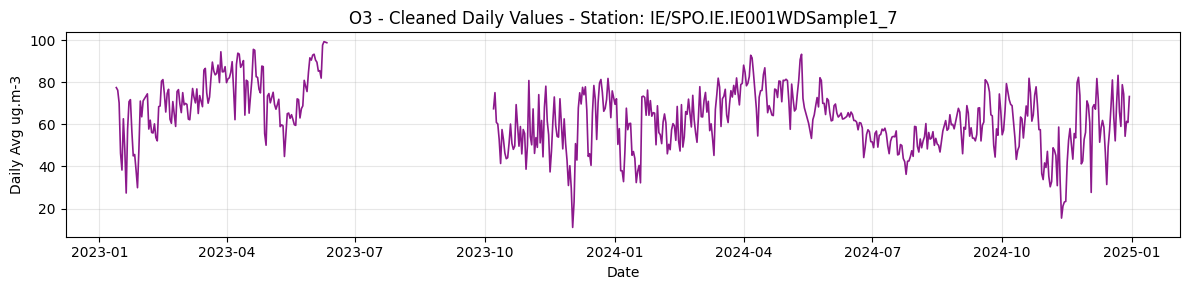

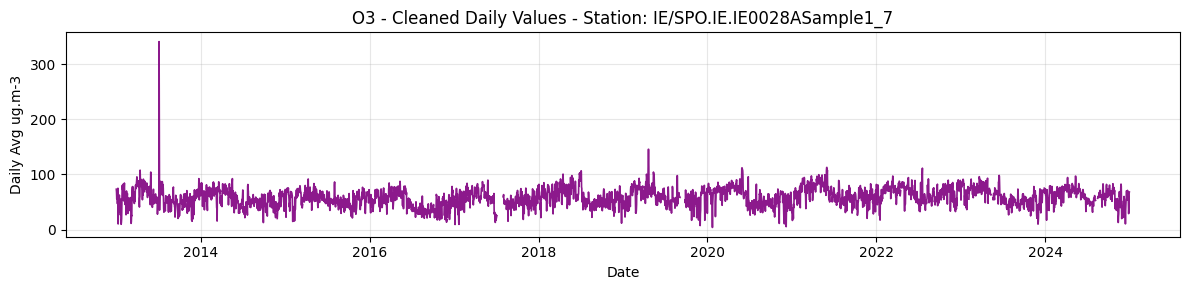

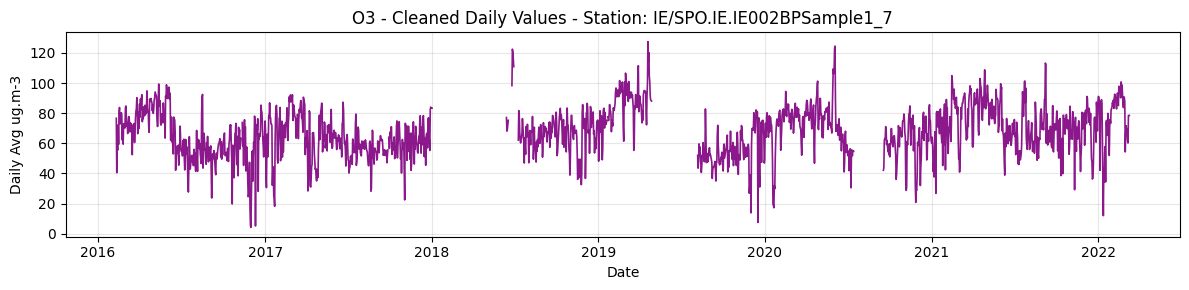

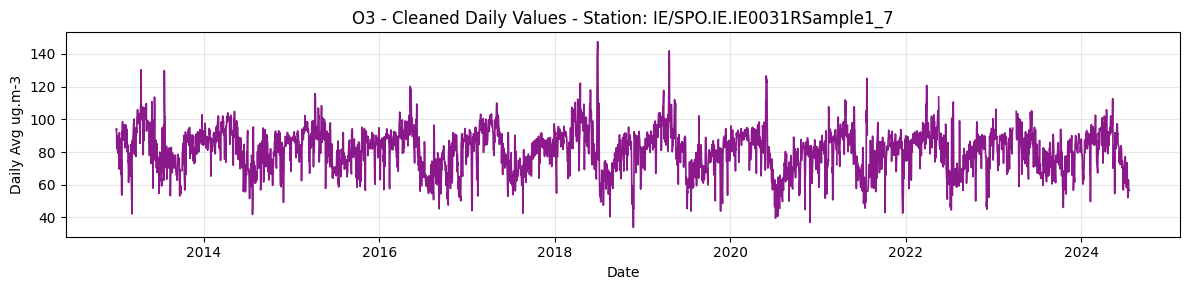

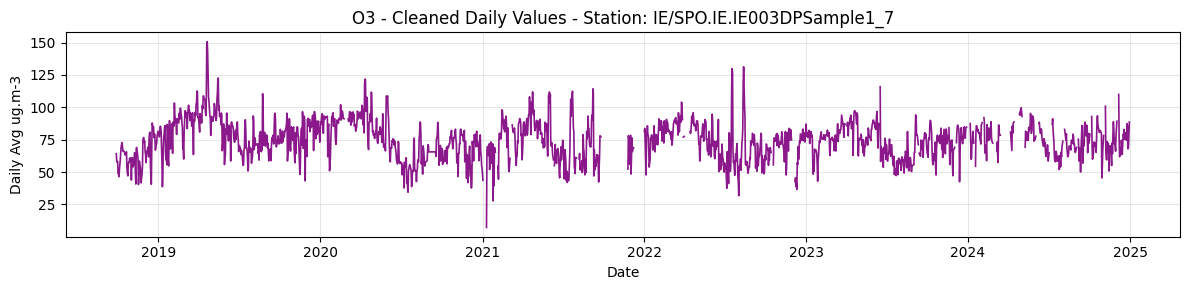

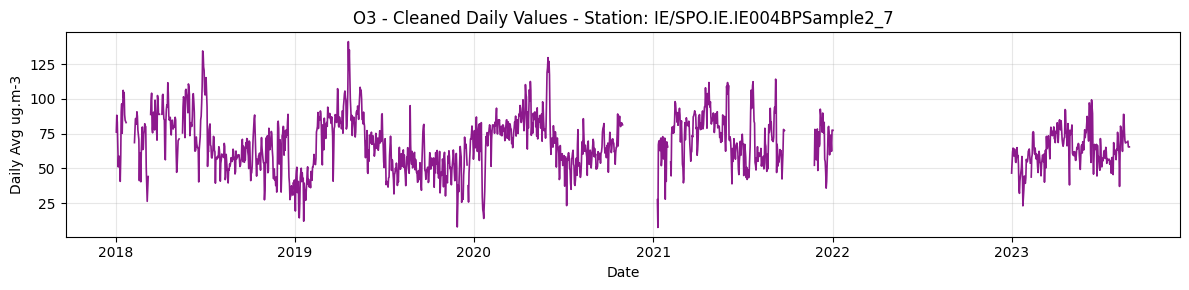

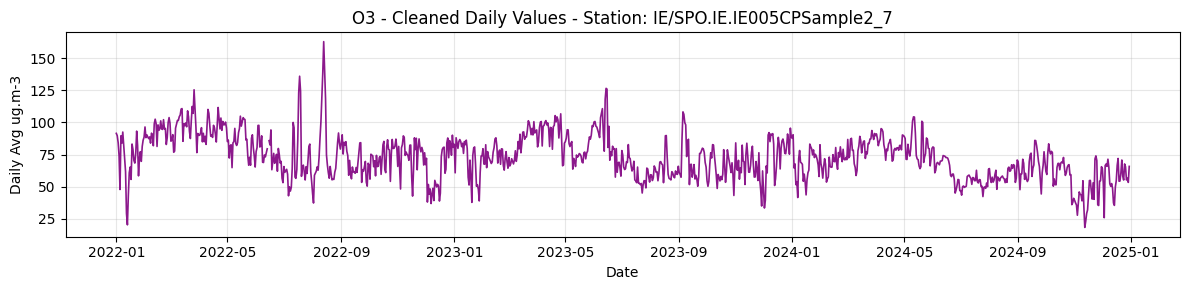

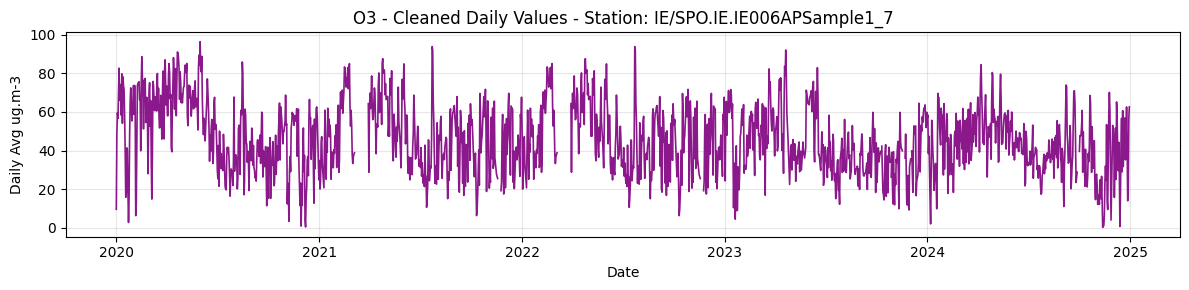

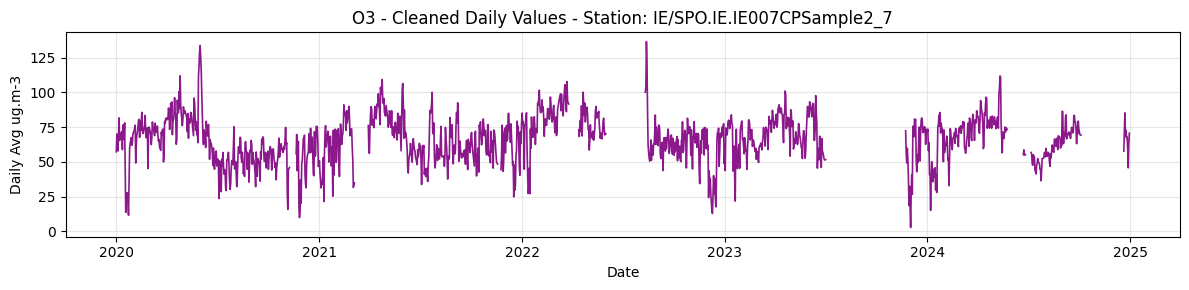

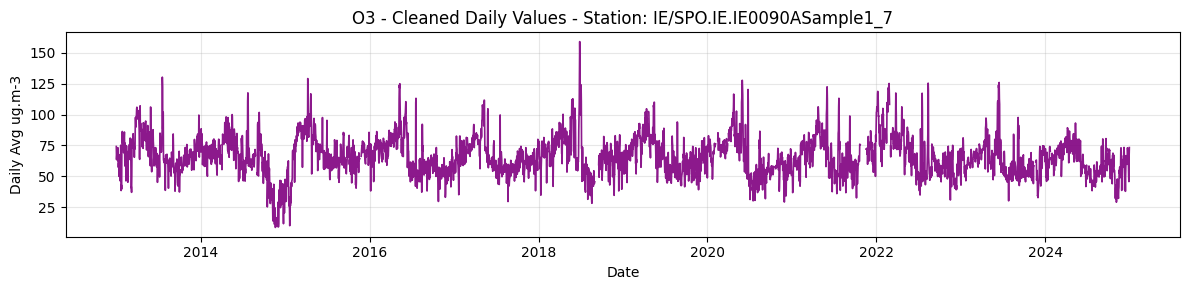

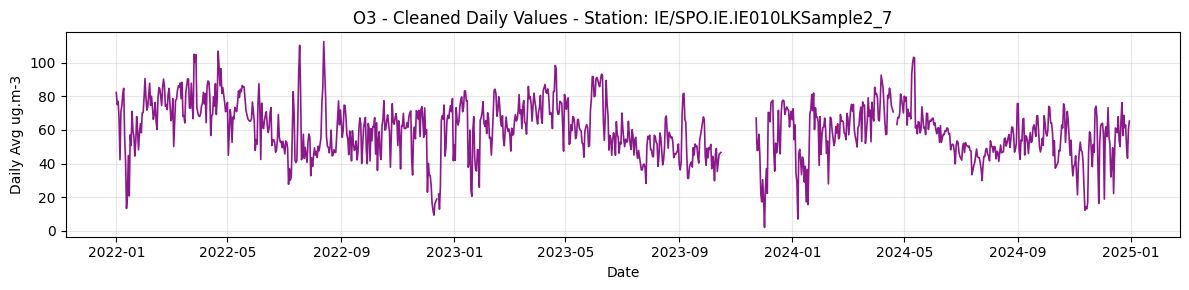

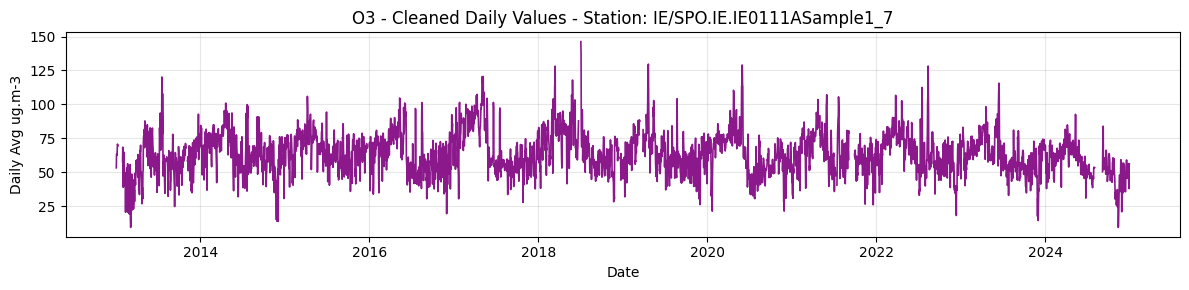

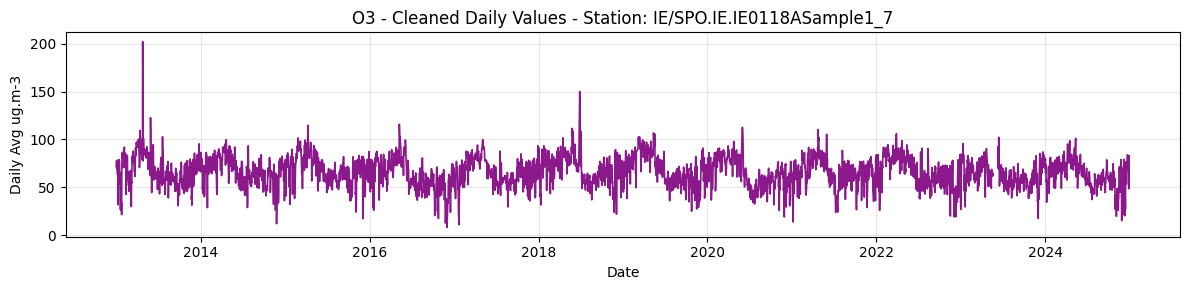

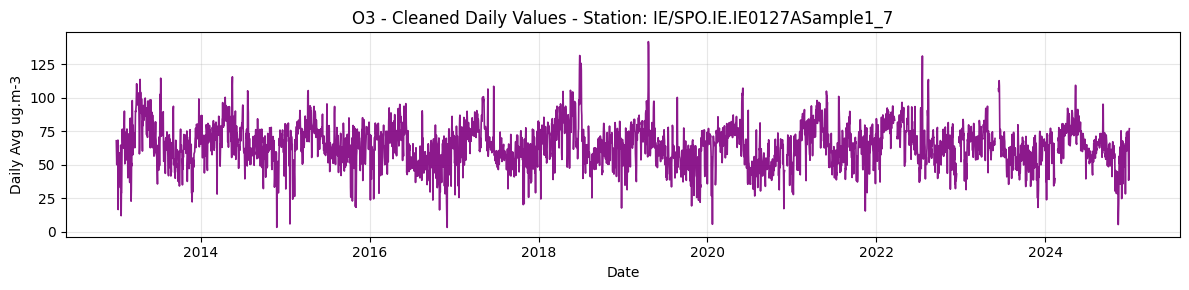

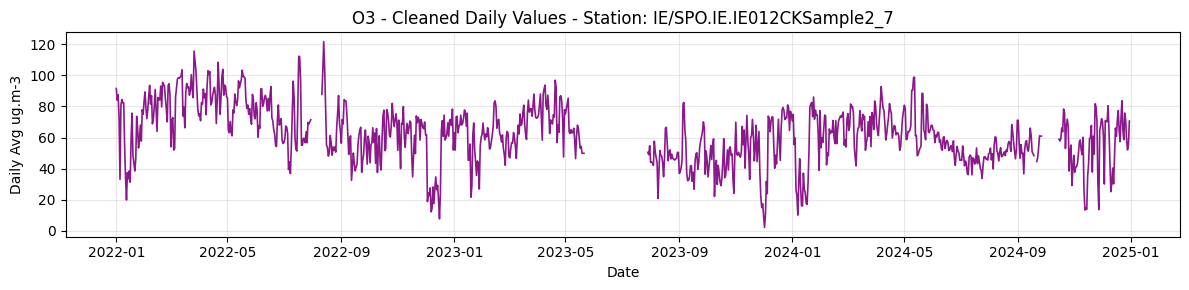

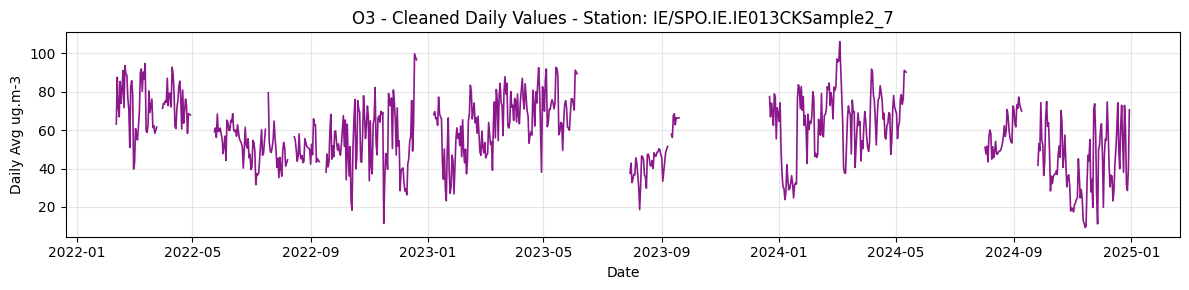

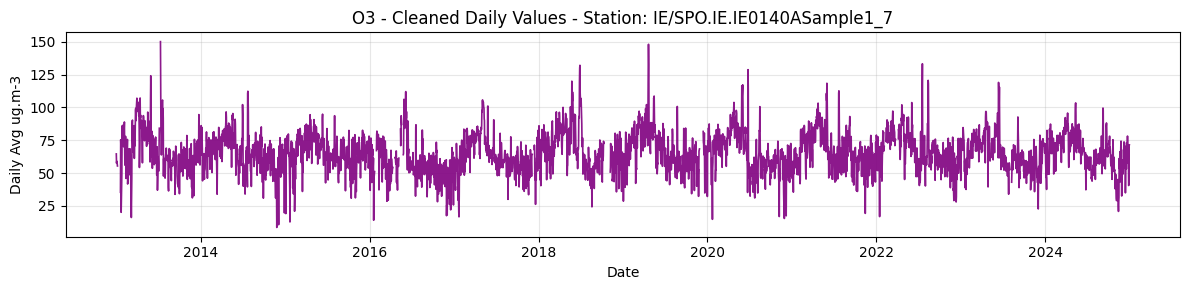

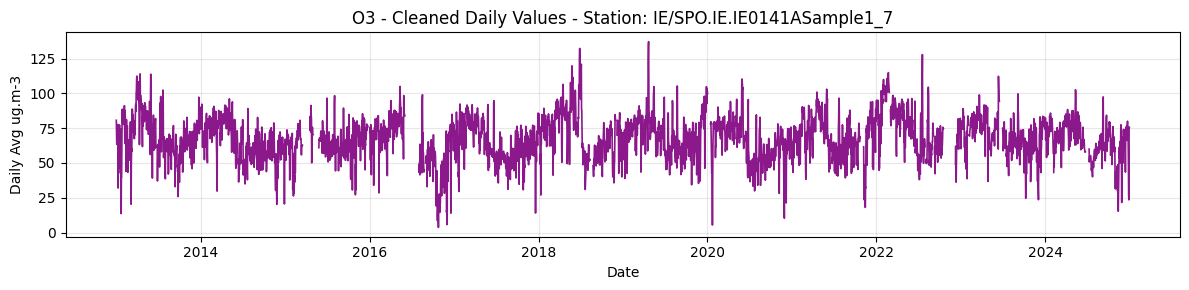

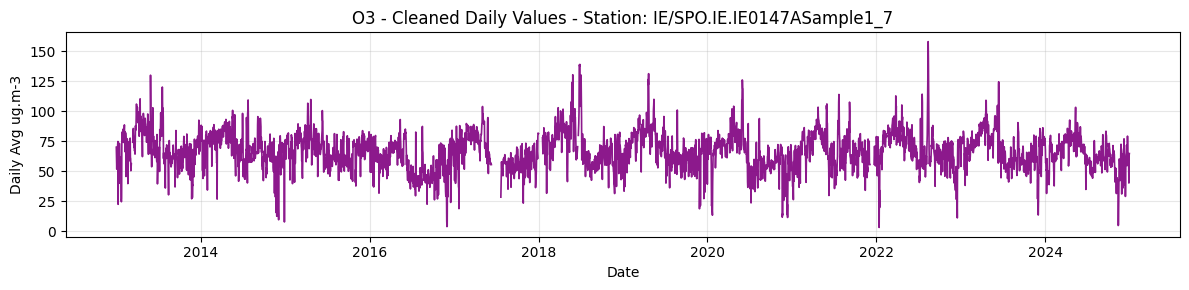

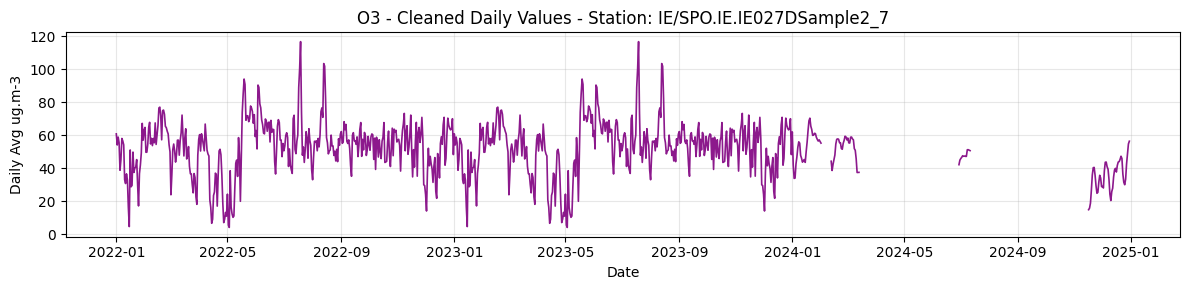

In [89]:
plot_dir = output_dir / "Cleaned_Daily_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily_Final['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily_Final[df_daily_Final['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='purple', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Cleaned Daily Values - Station: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleanData_Daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()